In [1]:
# -*- coding: utf-8 -*-
"""
--- START OF FILE mmb_3class_vid_aud_eeg_FINAL_refined.py --- # Refined Filename

Multimodal Emotion Recognition (3 Classes: Happy, Sad, Neutral)
- Video: FER-2013 (ResNet50 features, augmented) -> Mapped to Happy, Sad, Neutral
- Audio: RAVDESS (EfficientNetB0 features, optional pairing) -> Mapped to Happy, Sad, Neutral
- EEG: Bonn (Band Power features, augmented, heuristically mapped) -> Mapped to Happy, Sad, Neutral

Trains a 3-input model on 3 emotion classes using Keras/TensorFlow.
Includes data loading, preprocessing, augmentation, feature extraction,
model training, evaluation, and a live prediction component for Colab.

**LIMITATIONS:**
- Original 7 FER classes are mapped to 3 (Happy, Sad, Neutral). This merges distinct emotions.
- The Bonn EEG dataset mapping remains HEURISTIC and adapted for the 3 classes.
- Audio pairing between FER and RAVDESS is based on the mapped 3-class labels.
- Data imbalance from original FER persists but is handled differently due to merging.
"""

# Step 1: Install Required Libraries & Imports
# ============================================================
print("--- Step 1: Installing/Updating Libraries & Importing ---")
# Standard libs
import os, glob, random, time, io, gc, traceback, shutil
import numpy as np, pandas as pd, cv2
import re # For text processing in remedy generation
import zipfile # For potential manual extraction if needed
import multiprocessing # Standard lib

# TensorFlow / Keras
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # Suppress INFO logs
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Dense, Dropout, Concatenate, Reshape, Multiply,
                                     BatchNormalization, Activation, GlobalAveragePooling2D, Flatten, Attention) # Added Attention
from tensorflow.keras import regularizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.mixed_precision import Policy, set_global_policy
# Keras Applications
from tensorflow.keras.applications import ResNet50, EfficientNetB0
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess_input
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess_input
# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
# Plotting / Audio / Other
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.signal import welch
import librosa, soundfile as sf
from PIL import Image as PILImage
# Hugging Face Transformers (optional, for remedy generation)
try:
    from transformers import pipeline, AutoTokenizer, logging as hf_logging, set_seed
    hf_logging.set_verbosity_error() # Suppress verbose logs
    HUGGINGFACE_AVAILABLE = True
except ImportError:
    print("Hugging Face Transformers not installed. Remedy generation will be disabled.")
    pipeline = None; set_seed = lambda x: None
    HUGGINGFACE_AVAILABLE = False

# Colab specific imports & checks
try:
    from google.colab import files, output
    from IPython.display import display, Javascript, Image as IPImage
    from base64 import b64decode
    IN_COLAB = True
    print("Colab environment detected.")
except ImportError:
    print("Not running in Google Colab. Live capture/upload functionality will be disabled.")
    IN_COLAB = False
    # Define dummy functions/classes
    def display(*args, **kwargs): pass
    def Javascript(*args, **kwargs): pass
    def files(*args, **kwargs): return type('obj', (object,), {'upload': lambda: print("File upload only available in Colab.")})()
    def output(*args, **kwargs): return type('obj', (object,), {'eval_js': lambda x: None, 'register_callback': lambda x,y: None})()
    IPImage = lambda *args, **kwargs: None
    b64decode = lambda x: b""

print("Libraries imported.")

--- Step 1: Installing/Updating Libraries & Importing ---
Colab environment detected.
Libraries imported.


In [2]:
# Step 1.1: Configure Mixed Precision
# ============================================================
print("\n--- Step 1.1: Setting Mixed Precision Policy ---")
try:
    policy = Policy('mixed_float16')
    set_global_policy(policy)
    print(f"Mixed Precision Policy set: {policy.name}")
except Exception as e:
    print(f"Mixed precision setup failed: {e}. Using default float32.")



--- Step 1.1: Setting Mixed Precision Policy ---
Mixed Precision Policy set: mixed_float16


In [3]:
# Step 1.5: Configure Kaggle API
# ============================================================
print("\n--- Step 1.5: Configuring Kaggle API ---")
COLAB_FER_PATH = "/content/datasets/fer2013"
COLAB_BONN_PATH = "/content/datasets/bonn_eeg"
COLAB_RAVDESS_PATH = "/content/datasets/ravdess_audio"
kaggle_path = "/root/.kaggle/kaggle.json"
kaggle_setup_success = False
if os.path.exists(kaggle_path):
    print("Kaggle API configuration file already exists.")
    if oct(os.stat(kaggle_path).st_mode)[-3:] != '600':
        try: os.chmod(kaggle_path, 0o600); print("Corrected Kaggle API file permissions to 600.")
        except Exception as e: print(f"Warning: Could not set permissions for kaggle.json: {e}")
    kaggle_setup_success = True
elif IN_COLAB:
    print("Please upload your kaggle.json file using the button below:")
    try:
        uploaded = files.upload()
        time.sleep(2)
        if "kaggle.json" in uploaded:
            kaggle_dir = os.path.expanduser("~/.kaggle"); os.makedirs(kaggle_dir, exist_ok=True)
            shutil.move("kaggle.json", kaggle_path); os.chmod(kaggle_path, 0o600)
            print("Kaggle API configured successfully.")
            kaggle_setup_success = True
        else: print("ERROR: kaggle.json was not found in the uploaded files."); kaggle_setup_success = False
    except Exception as e: print(f"An error occurred during Kaggle setup: {e}"); traceback.print_exc(); kaggle_setup_success = False
else: print("Kaggle API file not found and not in Colab environment. Manual setup required if downloads needed."); kaggle_setup_success = False
if not kaggle_setup_success: print("WARNING: Kaggle API setup failed or skipped. Dataset downloads will be skipped.")
else: print("Kaggle API is ready.")



--- Step 1.5: Configuring Kaggle API ---
Please upload your kaggle.json file using the button below:


Saving kaggle.json to kaggle.json
Kaggle API configured successfully.
Kaggle API is ready.


In [16]:
# Step 1.6: Download datasets (Downloads original datasets, mapping happens in Step 6)
# ====================================================================
print("\n--- Step 1.6: Downloading Datasets (FER, Bonn, RAVDESS) ---")
# Define initial required Bonn categories for checking download structure
_INITIAL_BONN_CATEGORIES = ['Z', 'O', 'N', 'F', 'S']
fer_data_present = False; bonn_data_present = False; ravdess_data_present = False
if not kaggle_setup_success:
    print("\nSkipping dataset downloads as Kaggle API was not configured or setup failed.")
else:
    os.makedirs(COLAB_FER_PATH, exist_ok=True); os.makedirs(COLAB_BONN_PATH, exist_ok=True); os.makedirs(COLAB_RAVDESS_PATH, exist_ok=True)
    # --- Process FER-2013 ---
    # (Download/Verification logic - same as previous correct version, omitted for brevity)
    print("\nProcessing FER-2013...")
    fer_train_path_check = os.path.join(COLAB_FER_PATH, "train"); fer_test_path_check = os.path.join(COLAB_FER_PATH, "test")
    min_fer_dirs = 5
    fer_train_dirs_ok = os.path.isdir(fer_train_path_check) and len([d for d in os.listdir(fer_train_path_check) if os.path.isdir(os.path.join(fer_train_path_check, d))]) >= min_fer_dirs
    fer_test_dirs_ok = os.path.isdir(fer_test_path_check) and len([d for d in os.listdir(fer_test_path_check) if os.path.isdir(os.path.join(fer_test_path_check, d))]) >= min_fer_dirs
    if fer_train_dirs_ok and fer_test_dirs_ok: print(" FER-2013 'train' and 'test' directories already seem populated."); fer_data_present = True
    else:
        print(" FER-2013 directories missing or empty. Attempting download/extraction.");
        exit_code_fer = os.system(f"kaggle datasets download -d msambare/fer2013 -p {COLAB_FER_PATH} --unzip --force")
        if exit_code_fer == 0:
            time.sleep(3); fer_data_present = os.path.isdir(fer_train_path_check) and os.path.isdir(fer_test_path_check) and len(os.listdir(fer_train_path_check))>0 and len(os.listdir(fer_test_path_check))>0
            if fer_data_present: print(" FER-2013 download verified.")
            else: print(" ERROR: FER-2013 verification failed after download.");
        else: print(f" ERROR: FER-2013 download/extract failed (Code {exit_code_fer})."); fer_data_present = False
    # --- Process Bonn EEG ---
    # (Download and Reorganization logic - same as previous correct version, omitted for brevity)
    print("\nProcessing Bonn EEG...")
    bonn_folders_ok_initial = all(os.path.isdir(os.path.join(COLAB_BONN_PATH, f)) for f in _INITIAL_BONN_CATEGORIES)
    bonn_files_ok_initial = bool(glob.glob(os.path.join(COLAB_BONN_PATH, '**', '*.txt'), recursive=True))
    needs_bonn_download = not (bonn_folders_ok_initial and bonn_files_ok_initial)
    if needs_bonn_download:
         print(" Downloading Bonn EEG..."); exit_code_bonn = os.system(f"kaggle datasets download -d ashwanikumari/bonn-university-eeg -p {COLAB_BONN_PATH} --unzip --force")
         if exit_code_bonn != 0: print(f" ERROR: Bonn download failed (Code {exit_code_bonn}).")
    # Attempt reorganization
    # (Reorg logic omitted for brevity - same as previous correct version)
    # Final check based on initial categories
    bonn_folders_ok = all(os.path.isdir(os.path.join(COLAB_BONN_PATH, f)) for f in _INITIAL_BONN_CATEGORIES)
    bonn_files_ok = any(glob.glob(os.path.join(COLAB_BONN_PATH, cat, '*.txt')) for cat in _INITIAL_BONN_CATEGORIES)
    bonn_data_present = bonn_folders_ok and bonn_files_ok
    if bonn_data_present: print(" Bonn EEG data structure seems OK for loading.")
    else: print(" Warning: Bonn EEG data structure verification failed.")
    # --- Process RAVDESS Audio ---
    # (Download and Path Check logic - same as previous correct version, omitted for brevity)
    print("\nProcessing RAVDESS Audio...")
    ravdess_primary_path = os.path.join(COLAB_RAVDESS_PATH, "audio_speech_actors_01-24")
    ravdess_alt_path_check = os.path.join(COLAB_RAVDESS_PATH, "Actor_01")
    needs_ravdess_download = not (os.path.isdir(ravdess_primary_path) or os.path.isdir(ravdess_alt_path_check))
    if needs_ravdess_download:
        print(" Downloading RAVDESS Audio..."); exit_code_ravdess = os.system(f"kaggle datasets download -d uwrfkaggler/ravdess-emotional-speech-audio -p {COLAB_RAVDESS_PATH} --unzip --force")
        if exit_code_ravdess != 0: print(f" ERROR: RAVDESS download failed (Code {exit_code_ravdess}).")
    ravdess_data_present = os.path.isdir(ravdess_primary_path) or os.path.isdir(ravdess_alt_path_check)
    if ravdess_data_present: print(" RAVDESS dataset structure seems to exist.")
    else: print(" Warning: RAVDESS dataset structure not found.")

print("\n--- Dataset Setup Phase Complete ---")
print(f"FER-2013 Data Present: {fer_data_present}")
print(f"Bonn EEG Data Present: {bonn_data_present}")
print(f"RAVDESS Audio Data Present: {ravdess_data_present}")
if not fer_data_present: print("\nERROR: FER-2013 data is required but seems missing. Cannot proceed.")
elif not bonn_data_present: print("\nWARNING: Bonn EEG data missing/incomplete. EEG features will be zeros.")
elif not ravdess_data_present: print("\nWARNING: RAVDESS Audio data missing/incomplete. Audio features will be zeros.")



--- Step 1.6: Downloading Datasets (FER, Bonn, RAVDESS) ---

Processing FER-2013...
 FER-2013 'train' and 'test' directories already seem populated.

Processing Bonn EEG...
 Bonn EEG data structure seems OK for loading.

Processing RAVDESS Audio...
 RAVDESS dataset structure seems to exist.

--- Dataset Setup Phase Complete ---
FER-2013 Data Present: True
Bonn EEG Data Present: True
RAVDESS Audio Data Present: True


In [17]:
# <<< Step 3: Define Constants (MODIFIED FOR 3-CLASS) >>>
# ============================================================
print("\n--- Step 3: Defining Constants (3 Classes: Happy, Sad, Neutral) ---")
# Video Constants
VIDEO_TARGET_SIZE = (224, 224); VIDEO_CHANNELS = 3
# Audio Constants
AUDIO_TARGET_SIZE = (224, 224); AUDIO_CHANNELS = 3; AUDIO_SAMPLE_RATE = 16000
N_MELS = 128; AUDIO_N_FFT = 2048; AUDIO_HOP_LENGTH = 512; AUDIO_RECORD_DURATION_SEC = 4
# Target Classes (MODIFIED)
NUM_CLASSES = 3
CLASS_LABELS = {0: 'happy', 1: 'sad', 2: 'neutral'} # New 3-class labels
ORIG_FER_TO_3CLASS_MAP = {
    3: 0, # Original Happy -> New Happy (0)
    4: 1, # Original Sad -> New Sad (1)
    0: 1, # Original Angry -> New Sad (1)
    1: 1, # Original Disgust -> New Sad (1)
    2: 1, # Original Fear -> New Sad (1)
    6: 2, # Original Neutral -> New Neutral (2)
    5: 2, # Original Surprise -> New Neutral (2)
}
ORIG_FER_LABEL_NAMES = {0: 'angry', 1: 'disgust', 2: 'fear', 3: 'happy', 4: 'sad', 5: 'surprise', 6: 'neutral'}
ORIG_FER_NAME_TO_INDEX = {v: k for k, v in ORIG_FER_LABEL_NAMES.items()}
# EEG Constants
EEG_CHANNELS = 1; EEG_SIGNAL_LENGTH = 4097; EEG_SAMPLE_RATE_HZ = 173.61; NPERSEG_WELCH = 256
FREQ_BANDS = {"Theta": (4, 8), "Alpha": (8, 13), "Beta": (13, 30), "Gamma": (30, 50)}
NUM_EEG_FEATURES = len(FREQ_BANDS) * EEG_CHANNELS # = 4
# Feature Dimensions
RESNET50_FEATURE_DIM = 2048; EFFICIENTNETB0_FEATURE_DIM = 1280; EEG_FEATURE_DIM = NUM_EEG_FEATURES
# Mappings (MODIFIED)
RAVDESS_ORIG_TO_FER_MAP = {'01': 6, '02': 6, '03': 3, '04': 4, '05': 0, '06': 2, '07': 1, '08': 5}
RAVDESS_TO_3CLASS_MAP = {
    code: ORIG_FER_TO_3CLASS_MAP.get(orig_fer_label)
    for code, orig_fer_label in RAVDESS_ORIG_TO_FER_MAP.items()
    if ORIG_FER_TO_3CLASS_MAP.get(orig_fer_label) is not None
}
TARGET3_TO_BONN_MAP = {
    0: ['Z', 'O'],          # Happy (0) <- Orig Happy(3)
    1: ['S', 'F'],          # Sad (1)   <- Orig Sad(4), Angry(0), Disgust(1), Fear(2) -> S, S, S, F
    2: ['Z', 'O', 'N']      # Neutral (2) <- Orig Neutral(6), Surprise(5) -> Z, O, N, Z, O
}
BONN_CATEGORIES_TO_LOAD = sorted(list(set(cat for cats in TARGET3_TO_BONN_MAP.values() for cat in cats))) # ['F', 'N', 'O', 'S', 'Z']
# Zero Feature Placeholders
ZERO_VIDEO_FEAT = np.zeros(RESNET50_FEATURE_DIM, dtype=np.float32)
ZERO_AUDIO_FEAT = np.zeros(EFFICIENTNETB0_FEATURE_DIM, dtype=np.float32)
ZERO_EEG_FEAT = np.zeros(EEG_FEATURE_DIM, dtype=np.float32)
print(f"Constants defined for {NUM_CLASSES} classes ({', '.join(CLASS_LABELS.values())}).")
print(f"Required Bonn Categories for 3-Class mapping: {BONN_CATEGORIES_TO_LOAD}")


--- Step 3: Defining Constants (3 Classes: Happy, Sad, Neutral) ---
Constants defined for 3 classes (happy, sad, neutral).
Required Bonn Categories for 3-Class mapping: ['F', 'N', 'O', 'S', 'Z']


In [18]:
# Step 4: Load Pretrained Models (Remains the same)
# ============================================================
print("\n--- Step 4: Loading Pretrained Models ---")
base_model_vid = None; base_model_aud = None; text_generator = None
try:
    base_model_vid = ResNet50(weights='imagenet', include_top=False, input_shape=(VIDEO_TARGET_SIZE[0], VIDEO_TARGET_SIZE[1], VIDEO_CHANNELS), pooling='avg'); base_model_vid.trainable = False
    print(f"ResNet50 loaded. Output: {base_model_vid.output_shape}")
    if base_model_vid.output_shape[-1] != RESNET50_FEATURE_DIM: print(f"WARN: ResNet output {base_model_vid.output_shape[-1]} != constant {RESNET50_FEATURE_DIM}")
except Exception as e: print(f"Error loading ResNet50: {e}")
try:
    base_model_aud = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(AUDIO_TARGET_SIZE[0], AUDIO_TARGET_SIZE[1], AUDIO_CHANNELS), pooling='avg'); base_model_aud.trainable = False
    print(f"EfficientNetB0 loaded. Output: {base_model_aud.output_shape}")
    if base_model_aud.output_shape[-1] != EFFICIENTNETB0_FEATURE_DIM: print(f"WARN: EffNet output {base_model_aud.output_shape[-1]} != constant {EFFICIENTNETB0_FEATURE_DIM}")
except Exception as e: print(f"Error loading EfficientNetB0: {e}")
if HUGGINGFACE_AVAILABLE:
    try:
        model_name = "distilgpt2" # Lighter model
        print(f"Loading text generation pipeline: {model_name}...")
        pipeline_device_tf = 0 if tf.config.list_physical_devices('GPU') else -1
        text_generator = pipeline("text-generation", model=model_name, tokenizer=model_name, device=pipeline_device_tf)
        set_seed(42) # for reproducibility
        print(f"{model_name} text generation pipeline loaded.")
    except Exception as e: print(f"Text pipeline load error: {e}")
else: print("Skipping text generator loading.")
if base_model_vid is None or base_model_aud is None: raise RuntimeError("Essential base model loading failed.")
print("Pretrained models ready (or attempted).")



--- Step 4: Loading Pretrained Models ---
ResNet50 loaded. Output: (None, 2048)
EfficientNetB0 loaded. Output: (None, 1280)
Loading text generation pipeline: distilgpt2...
distilgpt2 text generation pipeline loaded.
Pretrained models ready (or attempted).


In [20]:
# Step 5: Feature Extraction & Augmentation Functions
# ============================================================
print("\n--- Step 5: Defining Feature Extraction & Augmentation Functions ---")

# --- Augmentation Functions ---

def augment_video(image_data):
    """
    Applies simple augmentations (random horizontal flip, brightness/contrast)
    to a single video frame (image).

    Args:
        image_data (np.ndarray): Input image (BGR or Grayscale).

    Returns:
        np.ndarray: Augmented image.
    """
    augmented_image = image_data.copy()
    # Random Horizontal Flip
    if random.random() < 0.4: # Probability of flipping
        augmented_image = cv2.flip(augmented_image, 1)
    # Random Brightness/Contrast Adjustment
    if random.random() < 0.3: # Probability of adjustment
        alpha = 1.0 + random.uniform(-0.2, 0.2) # Contrast factor (0.8 to 1.2)
        beta = random.uniform(-20, 20)          # Brightness shift (-20 to +20)
        # Apply adjustment and ensure clipping to valid range [0, 255]
        augmented_image = cv2.convertScaleAbs(augmented_image, alpha=alpha, beta=beta)
        # Explicit clip although convertScaleAbs often handles it
        augmented_image = np.clip(augmented_image, 0, 255)
    return augmented_image

def augment_audio(audio_data):
    """
    Applies simple augmentations (noise, time stretch, pitch shift)
    to audio data.

    Args:
        audio_data (np.ndarray): Input audio time series (1D float array).

    Returns:
        np.ndarray: Augmented audio time series, clipped to [-1.0, 1.0].
    """
    augmented_audio = audio_data.copy().astype(np.float32) # Work with float32 copy
    augmentation_type = random.choice(['noise', 'stretch', 'pitch', 'none'])

    try:
        # Add Gaussian Noise
        if augmentation_type == 'noise' and random.random() < 0.5:
            if augmented_audio.size > 0 and np.any(np.abs(augmented_audio) > 1e-6): # Check if signal has energy
                # Calculate noise amplitude relative to signal max amplitude
                noise_amp = 0.005 * np.random.uniform() * np.amax(np.abs(augmented_audio))
                noise = noise_amp * np.random.normal(size=augmented_audio.shape[0])
                augmented_audio += noise

        # Time Stretching
        elif augmentation_type == 'stretch' and random.random() < 0.3:
            # Ensure minimum length for stretching to be effective/stable
            if augmented_audio.size > 100:
                rate = np.random.uniform(0.85, 1.15) # Stretch factor
                # Ensure input is float32 for librosa effects
                stretched_audio = librosa.effects.time_stretch(y=augmented_audio, rate=rate)
                # Use stretched audio only if it produced valid output
                if stretched_audio.size > 0:
                     augmented_audio = stretched_audio

        # Pitch Shifting
        elif augmentation_type == 'pitch' and random.random() < 0.3:
             if augmented_audio.size > 0:
                n_steps = np.random.uniform(-2, 2) # Shift pitch by +/- 2 semitones
                augmented_audio = librosa.effects.pitch_shift(y=augmented_audio, sr=AUDIO_SAMPLE_RATE, n_steps=n_steps)

        # 'none' case requires no action

    except Exception as e:
        # print(f"  Warning: Audio augmentation failed ({augmentation_type}): {e}") # Optional warning
        pass # Ignore augmentation error, return original or partially augmented

    # Clip final audio to standard [-1.0, 1.0] range
    return np.clip(augmented_audio, -1.0, 1.0)

def augment_eeg(eeg_signal, noise_factor=0.01, scale_range=0.1):
    """
    Applies simple augmentations (Gaussian noise, amplitude scaling)
    to an EEG signal segment.

    Args:
        eeg_signal (np.ndarray): Input EEG signal (1D float array).
        noise_factor (float): Factor to scale noise relative to signal std dev.
        scale_range (float): Range (+/-) for random amplitude scaling factor.

    Returns:
        np.ndarray: Augmented EEG signal.
    """
    augmented_signal = eeg_signal.copy().astype(float) # Work with float copy
    try:
        # Add Gaussian Noise
        if random.random() < 0.5: # Probability of adding noise
            signal_std = np.std(augmented_signal)
            # Add noise only if signal has variance (not flat zero)
            if signal_std > 1e-6: # Check for non-zero std dev
                 noise = np.random.normal(0, signal_std * noise_factor, augmented_signal.shape)
                 augmented_signal += noise

        # Scale Signal Amplitude
        if random.random() < 0.3: # Probability of scaling
            scale_factor = 1.0 + random.uniform(-scale_range, scale_range)
            augmented_signal *= scale_factor

    except Exception as e:
        # print(f"  Warning: EEG augmentation failed: {e}") # Optional warning
        pass # Return original or partially augmented if error

    return augmented_signal


# --- Feature Extraction Functions ---

def extract_video_features(image_data, augment=False):
    """
    Extracts features from a single image using the preloaded ResNet50 base model.
    Handles grayscale/color conversion, resizing, and preprocessing.

    Args:
        image_data (np.ndarray): Input image (can be grayscale or BGR/BGRA).
        augment (bool): Whether to apply augmentation before feature extraction.

    Returns:
        np.ndarray: Flattened feature vector (float32) or a zero vector on failure.
    """
    global base_model_vid # Access the globally loaded ResNet50 model
    if base_model_vid is None:
        print("VidFeat Error: ResNet50 base model not loaded.")
        return ZERO_VIDEO_FEAT

    try:
        # Input validation
        if not isinstance(image_data, np.ndarray) or image_data.ndim < 2 :
            # print("VidFeat Warn: Invalid input type or dimensions.") # Optional debug
            return ZERO_VIDEO_FEAT

        frame_processed = image_data.copy()

        # Apply augmentation if requested
        if augment:
            frame_processed = augment_video(frame_processed)

        # Robust color conversion to RGB (expected by ResNet50 preprocess_input)
        if frame_processed.ndim == 2: # Grayscale
            frame_rgb = cv2.cvtColor(frame_processed, cv2.COLOR_GRAY2RGB)
        elif frame_processed.ndim == 3:
            channels = frame_processed.shape[-1]
            if channels == 1: # Grayscale with channel dim
                frame_rgb = cv2.cvtColor(frame_processed, cv2.COLOR_GRAY2RGB)
            elif channels == 4: # Assume BGRA/RGBA -> Convert to RGB
                frame_rgb = cv2.cvtColor(frame_processed, cv2.COLOR_BGRA2RGB) # Handles both BGR(A) order
            elif channels == 3: # Assume BGR -> Convert to RGB
                frame_rgb = cv2.cvtColor(frame_processed, cv2.COLOR_BGR2RGB)
            else:
                # print(f"VidFeat Warn: Unsupported channel count: {channels}") # Optional debug
                return ZERO_VIDEO_FEAT
        else:
             # print(f"VidFeat Warn: Unsupported image dimensions: {frame_processed.ndim}") # Optional debug
             return ZERO_VIDEO_FEAT

        # Resize if necessary to the target input size for ResNet50
        if frame_rgb.shape[:2] != VIDEO_TARGET_SIZE:
            # Use appropriate interpolation method based on scaling direction
            interp = cv2.INTER_AREA if frame_rgb.shape[0] > VIDEO_TARGET_SIZE[0] else cv2.INTER_LINEAR
            frame_resized = cv2.resize(frame_rgb, VIDEO_TARGET_SIZE, interpolation=interp)
        else:
            frame_resized = frame_rgb

        # Preprocess the image for ResNet50 and add batch dimension
        # Ensure input is float32 for preprocessing function
        frame_preprocessed = resnet_preprocess_input(frame_resized.astype(np.float32))
        frame_batch = np.expand_dims(frame_preprocessed, axis=0)

        # Predict features (verbose=0 suppresses prediction progress bar)
        # Use with tf.device('/cpu:0'): if base model prediction causes GPU memory issues inside loop
        features = base_model_vid.predict(frame_batch, verbose=0)

        # Return flattened features as float32
        return features.flatten().astype(np.float32)

    except Exception as e:
        print(f"VidFeat Error processing image: {e}")
        # traceback.print_exc() # Uncomment for detailed traceback
        return ZERO_VIDEO_FEAT

def extract_audio_features(audio_input, sr=AUDIO_SAMPLE_RATE, n_mels=N_MELS,
                           n_fft=AUDIO_N_FFT, hop_length=AUDIO_HOP_LENGTH,
                           target_size=AUDIO_TARGET_SIZE, augment=False):
    """
    Extracts features from audio using Mel Spectrogram and a preloaded EfficientNetB0 base model.
    Handles different input types (path, numpy array, BytesIO) and preprocessing.

    Args:
        audio_input (str | np.ndarray | io.BytesIO): Audio source.
        sr (int): Target sample rate.
        n_mels (int): Number of Mel bands to generate.
        n_fft (int): FFT window size.
        hop_length (int): Hop length for FFT.
        target_size (tuple): Target (height, width) for the spectrogram image.
        augment (bool): Whether to apply augmentation.

    Returns:
        np.ndarray: Flattened feature vector (float32) or a zero vector on failure.
    """
    global base_model_aud # Access the globally loaded EfficientNetB0 model
    if base_model_aud is None:
        print("AudFeat Error: EfficientNetB0 base model not loaded.")
        return ZERO_AUDIO_FEAT

    y = None # Initialize audio time series
    effective_sr = sr # Assume target sample rate initially

    try:
        # Load audio based on input type
        if isinstance(audio_input, str): # File path
            if os.path.exists(audio_input):
                y, effective_sr = librosa.load(audio_input, sr=sr, mono=True)
            else:
                # print(f"AudFeat Warn: File not found {audio_input}") # Optional debug
                return ZERO_AUDIO_FEAT
        elif isinstance(audio_input, np.ndarray): # Numpy array
            y = audio_input.astype(np.float32) # Ensure float32
            if y.ndim > 1: y = np.mean(y, axis=-1) # Convert to mono if necessary
        elif isinstance(audio_input, io.BytesIO): # BytesIO object
             audio_input.seek(0) # Ensure start
             try: # Try soundfile first
                 y, effective_sr = sf.read(audio_input, dtype='float32')
                 if y.ndim > 1: y = np.mean(y, axis=-1) # Ensure mono
             except Exception: # Fallback to librosa
                 audio_input.seek(0); y, effective_sr = librosa.load(audio_input, sr=sr, mono=True)
        else:
            # print(f"AudFeat Warn: Unsupported input type: {type(audio_input)}") # Optional debug
            return ZERO_AUDIO_FEAT

        # Basic validation of loaded audio
        min_audio_len = hop_length * 5 # Need a minimum length for processing
        if y is None or len(y) < min_audio_len:
            # print("AudFeat Warn: Audio too short or failed to load.") # Optional debug
            return ZERO_AUDIO_FEAT

        # Resample if necessary
        if effective_sr != sr:
            y = librosa.resample(y=y, orig_sr=effective_sr, target_sr=sr)
            effective_sr = sr # Update effective SR

        # Apply augmentation if requested
        if augment:
            y = augment_audio(y)
            if y is None or len(y) < min_audio_len: # Re-check length
                 # print("AudFeat Warn: Audio too short after augmentation.") # Optional debug
                 return ZERO_AUDIO_FEAT

        # Calculate Mel Spectrogram
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels)
        # Convert to Log Mel Spectrogram (dB scale)
        log_mel_spec = librosa.power_to_db(mel_spec, ref=np.max)

        # Check for minimum width (time steps)
        if log_mel_spec.shape[1] < 5:
            # print("AudFeat Warn: Spectrogram too narrow.") # Optional debug
            return ZERO_AUDIO_FEAT

        # Normalize spectrogram to [0, 1] range, then scale to [0, 255] uint8 for imaging
        spec_min, spec_max = log_mel_spec.min(), log_mel_spec.max()
        log_mel_spec_norm = (log_mel_spec - spec_min) / (spec_max - spec_min + 1e-6) # Epsilon for stability
        log_mel_spec_img = (log_mel_spec_norm * 255).astype(np.uint8)

        # Resize spectrogram image to the target size for EfficientNet
        spec_resized = cv2.resize(log_mel_spec_img, target_size, interpolation=cv2.INTER_LINEAR)

        # Convert grayscale spectrogram to 3 channels (RGB)
        spec_3channel = cv2.cvtColor(spec_resized, cv2.COLOR_GRAY2RGB)

        # Preprocess the image for EfficientNetB0 and add batch dimension
        spec_preprocessed = efficientnet_preprocess_input(spec_3channel.astype(np.float32)) # Ensure float32
        spec_batch = np.expand_dims(spec_preprocessed, axis=0)

        # Predict features
        # Use with tf.device('/cpu:0'): if GPU memory issues
        features = base_model_aud.predict(spec_batch, verbose=0)

        # Return flattened features as float32
        return features.flatten().astype(np.float32)

    except Exception as e:
        print(f"AudFeat Error processing audio: {e}")
        # traceback.print_exc() # Uncomment for detailed traceback
        return ZERO_AUDIO_FEAT

def calculate_band_power_single_channel(eeg_signal, sfreq=EEG_SAMPLE_RATE_HZ, bands=FREQ_BANDS, nperseg=NPERSEG_WELCH):
    """
    Calculates the average power in specified frequency bands for a single EEG channel
    using Welch's method.

    Args:
        eeg_signal (np.ndarray): 1D EEG signal data.
        sfreq (float): Sampling frequency of the EEG signal.
        bands (dict): Dictionary defining frequency bands, e.g., {"Alpha": (8, 13)}.
        nperseg (int): Length of each segment for Welch's method.

    Returns:
        np.ndarray: Array containing the average power for each band, or zeros on error.
    """
    band_powers = []
    target_size = len(bands)
    eeg_signal = eeg_signal.astype(float) # Ensure float

    # Input validation for Welch's method
    if len(eeg_signal) < nperseg:
        # print(f"EEG BandPower Warn: Signal length ({len(eeg_signal)}) < nperseg ({nperseg}).")
        return np.zeros(target_size, dtype=np.float32)
    if np.any(np.isnan(eeg_signal)) or np.any(np.isinf(eeg_signal)):
        # print("EEG BandPower Warn: Signal contains NaN or Inf.")
        return np.zeros(target_size, dtype=np.float32)

    try:
        # Calculate Power Spectral Density (PSD)
        freqs, psd = welch(eeg_signal, fs=sfreq, nperseg=nperseg, nfft=max(nperseg, 512))
    except ValueError as ve: # Catch specific Welch errors
         print(f"Welch Error calculating PSD: {ve}. Signal length: {len(eeg_signal)}, nperseg: {nperseg}")
         return np.zeros(target_size, dtype=np.float32)
    except Exception as e:
        print(f"Welch Error calculating PSD: {e}")
        return np.zeros(target_size, dtype=np.float32)

    # Calculate average power per band
    for band_name, (low_f, high_f) in bands.items():
        band_mask = (freqs >= low_f) & (freqs < high_f)
        if np.sum(band_mask) > 0:
             avg_p = np.mean(psd[band_mask])
             band_powers.append(avg_p if not np.isnan(avg_p) else 0.0) # Handle potential NaNs
        else:
            band_powers.append(0.0) # Zero power if band is empty

    output_p = np.array(band_powers, dtype=np.float32)

    # Final check for correct output shape
    return output_p if output_p.shape[0] == target_size else np.zeros(target_size, dtype=np.float32)

def process_bonn_eeg_signal(eeg_signal):
    """
    Processes a raw Bonn EEG signal segment: calculates normalized band power features.

    Args:
        eeg_signal (np.ndarray): 1D raw EEG signal data of length EEG_SIGNAL_LENGTH.

    Returns:
        np.ndarray: Normalized feature vector (Z-score) or a zero vector on failure.
    """
    target_feature_size = NUM_EEG_FEATURES # Expected output dimension

    try:
        # Input Validation
        if not isinstance(eeg_signal, np.ndarray) or eeg_signal.ndim != 1:
            # print("EEG Process Warn: Input not a 1D numpy array.") # Optional debug
            return ZERO_EEG_FEAT
        if len(eeg_signal) != EEG_SIGNAL_LENGTH:
            # print(f"EEG Process Warn: Incorrect length {len(eeg_signal)}, expected {EEG_SIGNAL_LENGTH}.") # Optional debug
            return ZERO_EEG_FEAT
        if np.any(np.isnan(eeg_signal)) or np.any(np.isinf(eeg_signal)):
             # print("EEG Process Warn: Signal contains NaN or Inf.") # Optional debug
             return ZERO_EEG_FEAT

        # 1. Calculate band power features
        features = calculate_band_power_single_channel(
            eeg_signal, sfreq=EEG_SAMPLE_RATE_HZ, bands=FREQ_BANDS, nperseg=NPERSEG_WELCH
        )

        # Validate feature vector shape and content
        if features.shape[0] != target_feature_size:
            # print(f"EEG Process Warn: Incorrect feature dimension ({features.shape[0]} vs {target_feature_size}).") # Optional debug
            return ZERO_EEG_FEAT
        if np.any(np.isnan(features)) or np.any(np.isinf(features)):
            # print("EEG Process Warn: Features contain NaN/Inf after band power calculation.") # Optional debug
            return ZERO_EEG_FEAT

        # 2. Normalize features (Z-score across the features for this signal sample)
        mean = np.mean(features)
        std = np.std(features)
        features_norm = (features - mean) / (std + 1e-7) # Epsilon for stability

        # Final check for NaNs after normalization
        if np.any(np.isnan(features_norm)):
            # print("EEG Process Warn: NaN detected after normalization.") # Optional debug
            return ZERO_EEG_FEAT

        return features_norm.astype(np.float32) # Ensure float32 output

    except Exception as e:
        print(f"EEG Process Error: Unexpected error: {e}")
        # traceback.print_exc() # Uncomment for detailed traceback
        return ZERO_EEG_FEAT

print("Feature extraction and augmentation functions defined.")


--- Step 5: Defining Feature Extraction & Augmentation Functions ---
Feature extraction and augmentation functions defined.


In [21]:
# <<< Step 6: Data Loading Function (Corrected 3-Class Version) >>>
# ======================================================================================
print("\n--- Step 6: Defining Data Loading Function (3-Class Version with Fixes) ---")

# Function definition includes case-insensitive glob and to_categorical fix
def load_and_preprocess_data_3class(fer_path, ravdess_path, bonn_path,
                                    max_samples_per_class=None, # Limit applies to the 3 target classes
                                    max_bonn_total=1000,      # Limit total raw Bonn signals processed
                                    augment_prob=0.5,         # Probability for video augmentation
                                    eeg_augment_factor=1):    # How many augmented EEG versions per raw signal
    """Loads data for 3 classes (Happy, Sad, Neutral) using specified mappings:
       - FER images (mapped from 7 classes based on ORIG_FER_TO_3CLASS_MAP).
       - Optional RAVDESS audio (mapped based on RAVDESS_TO_3CLASS_MAP).
       - Heuristic/augmented Bonn EEG (mapped based on TARGET3_TO_BONN_MAP).
       Handles case-insensitive EEG file extensions (.txt/.TXT). Corrects to_categorical usage.
    """
    all_features_vid, all_features_aud, all_labels = [], [], [] # Using 'all_labels' for the final 3-class labels
    fer_loaded_count, ravdess_paired_count, raw_bonn_signals_loaded = 0, 0, 0
    eeg_features_generated, total_eeg_assignments, eeg_paired_count, missing_eeg_pool_count = 0, 0, 0, 0

    start_time = time.time()

    # --- 1. Load FER Data (Mapping from 7 classes in folders) ---
    print("Loading FER-2013 (from image folders) and mapping to 3 classes...")
    fer_train_dir = os.path.join(fer_path, "train")
    if not os.path.isdir(fer_train_dir): print(f"ERROR: FER train dir not found: {fer_train_dir}"); return None, None, None, None, False
    target_samples_count = {i: 0 for i in range(NUM_CLASSES)}
    emotion_dirs_orig = sorted([d for d in os.listdir(fer_train_dir) if os.path.isdir(os.path.join(fer_train_dir, d)) and d in ORIG_FER_NAME_TO_INDEX])
    print(f"Processing original FER directories in {fer_train_dir}...")
    if not emotion_dirs_orig: print(f"ERROR: No valid emotion directories found in {fer_train_dir}."); return None, None, None, None, False

    for emotion_label_orig in emotion_dirs_orig:
        orig_class_index = ORIG_FER_NAME_TO_INDEX.get(emotion_label_orig)
        target_class_index = ORIG_FER_TO_3CLASS_MAP.get(orig_class_index)
        if target_class_index is None: continue
        emotion_dir_path = os.path.join(fer_train_dir, emotion_label_orig)
        image_files = glob.glob(os.path.join(emotion_dir_path, '*.png')) + glob.glob(os.path.join(emotion_dir_path, '*.jpg')) + glob.glob(os.path.join(emotion_dir_path, '*.jpeg'))
        if not image_files: continue
        print(f"  Processing class '{emotion_label_orig}' ({len(image_files)} images) -> maps to Target Class {target_class_index} ({CLASS_LABELS[target_class_index]})...")
        processed_in_class = 0; random.shuffle(image_files)
        for img_path in image_files:
            if max_samples_per_class is not None and target_samples_count.get(target_class_index, 0) >= max_samples_per_class: break
            try:
                image_gray = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if image_gray is None: continue
                if image_gray.shape != (48, 48): image_gray = cv2.resize(image_gray, (48, 48), interpolation=cv2.INTER_AREA)
                augment_this_vid_sample = random.random() < augment_prob
                vid_feat = extract_video_features(image_gray, augment=augment_this_vid_sample)
                if np.any(vid_feat):
                    all_features_vid.append(vid_feat); all_features_aud.append(ZERO_AUDIO_FEAT); all_labels.append(target_class_index)
                    target_samples_count[target_class_index] += 1; fer_loaded_count += 1; processed_in_class += 1
            except Exception as e: print(f"    Img Error processing {img_path}: {e}")
    print(f"\nFinished FER loading. Total images loaded: {fer_loaded_count}. Target 3-Class Counts: {target_samples_count}")
    if fer_loaded_count == 0: print("ERROR: No FER images loaded."); return None, None, None, None, False

    # --- 2. Load RAVDESS Data & Pair (Using 3-Class Map) ---
    print("\nLoading RAVDESS & pairing (using 3-class map)...")
    ravdess_primary_dir = os.path.join(ravdess_path, "audio_speech_actors_01-24"); ravdess_alt_path_check = os.path.join(ravdess_path, "Actor_01")
    ravdess_base_dir = None
    if os.path.isdir(ravdess_primary_dir): ravdess_base_dir = ravdess_primary_dir
    elif os.path.isdir(ravdess_alt_path_check): ravdess_base_dir = ravdess_path
    else: print(f" Warning: RAVDESS directory not found at expected locations.")
    if ravdess_base_dir and ravdess_data_present:
        print(f" Using RAVDESS base directory: {ravdess_base_dir}")
        wav_files = glob.glob(os.path.join(ravdess_base_dir, "**", "*.wav"), recursive=True); print(f" Found {len(wav_files)} potential RAVDESS .wav files.")
        random.shuffle(wav_files)
        indices_by_target_class = {i: [] for i in range(NUM_CLASSES)}; [indices_by_target_class[label].append(idx) for idx, label in enumerate(all_labels)]
        available_indices_set_by_class = {i: set(indices) for i, indices in indices_by_target_class.items()}
        audio_paired_per_target_class = {i: 0 for i in range(NUM_CLASSES)}
        for audio_path in wav_files:
            try:
                filename = os.path.basename(audio_path); parts = filename.split('.')[0].split('-')
                if len(parts) >= 7:
                    ravdess_emotion_code = parts[2]; target_label = RAVDESS_TO_3CLASS_MAP.get(ravdess_emotion_code)
                    if target_label is not None:
                        available_indices = available_indices_set_by_class.get(target_label)
                        if not available_indices: continue
                        idx_to_fill = available_indices.pop(); aud_feat = extract_audio_features(audio_path, augment=False)
                        if np.any(aud_feat): all_features_aud[idx_to_fill] = aud_feat; ravdess_paired_count += 1; audio_paired_per_target_class[target_label] += 1
                        else: available_indices_set_by_class[target_label].add(idx_to_fill)
            except Exception as e: print(f"    RAVDESS Error processing {audio_path}: {e}")
        print(f"Finished RAVDESS pairing. Total paired: {ravdess_paired_count}. Audio Paired per Target Class: {audio_paired_per_target_class}")
    else: print("Skipping RAVDESS pairing (directory not found or data flagged missing in Step 1.6).")

    # --- 3. Load, Augment, Process Bonn EEG (Using 3-Class Map & Case-Insensitive Glob) ---
    print("\nLoading/Augmenting/Processing Bonn EEG (using 3-class map)...")
    augmented_eeg_pools = {i: [] for i in range(NUM_CLASSES)}
    bonn_cat_to_target_map = {cat: [] for cat in BONN_CATEGORIES_TO_LOAD};
    for target_lbl, cats in TARGET3_TO_BONN_MAP.items():
        for c in cats:
            if c in bonn_cat_to_target_map:
                if target_lbl not in bonn_cat_to_target_map[c]: bonn_cat_to_target_map[c].append(target_lbl)
    if not bonn_data_present: print(f"WARNING: Bonn EEG data flagged missing/incomplete in Step 1.6. Skipping EEG loading.")
    elif not os.path.isdir(bonn_path): print(f"ERROR: Bonn EEG path not found: {bonn_path}. Skipping EEG loading.")
    else:
        for bonn_cat in BONN_CATEGORIES_TO_LOAD:
            cat_path = os.path.join(bonn_path, bonn_cat); target_labels_for_cat = bonn_cat_to_target_map.get(bonn_cat, [])
            if not target_labels_for_cat: continue
            if not os.path.isdir(cat_path): print(f"  Warning: Bonn category directory missing: {cat_path}"); continue
            # <<< FIX: Glob for both .txt and .TXT >>>
            files = glob.glob(os.path.join(cat_path, "*.txt")) + glob.glob(os.path.join(cat_path, "*.TXT"))
            if not files: print(f"  Warning: No .txt or .TXT files found in {cat_path}"); continue
            print(f"  Loading Bonn '{bonn_cat}' ({len(files)} files) -> Target Labels: {target_labels_for_cat}")
            random.shuffle(files)
            for eeg_path in files:
                if max_bonn_total is not None and raw_bonn_signals_loaded >= max_bonn_total: break
                try:
                    eeg_df = pd.read_csv(eeg_path, header=None);
                    if eeg_df.shape[1] != 1: continue
                    eeg_sig = eeg_df.values.flatten()
                    if len(eeg_sig) == EEG_SIGNAL_LENGTH:
                        raw_bonn_signals_loaded += 1
                        for _ in range(eeg_augment_factor):
                            aug_sig = augment_eeg(eeg_sig); eeg_feat = process_bonn_eeg_signal(aug_sig)
                            if np.any(eeg_feat):
                                eeg_features_generated += 1
                                for target_lbl in target_labels_for_cat: augmented_eeg_pools[target_lbl].append(eeg_feat)
                                total_eeg_assignments += 1
                except pd.errors.EmptyDataError: continue # Skip empty files silently
                except Exception as e: print(f"    EEG Error loading/processing {eeg_path}: {e}")
            if max_bonn_total is not None and raw_bonn_signals_loaded >= max_bonn_total: print(f"Reached Bonn loading limit ({max_bonn_total})."); break
        print(f"\nFinished Bonn processing. Raw signals loaded: {raw_bonn_signals_loaded}, Features generated: {eeg_features_generated}, Pool assignments: {total_eeg_assignments}")
        for lbl, feats in augmented_eeg_pools.items(): print(f"  Target Class {lbl} ({CLASS_LABELS.get(lbl,'?')}) EEG Pool Size: {len(feats)}")

    # --- 4. Pair EEG & Finalize ---
    print("\nPairing EEG features with loaded samples...")
    final_eeg_features = []
    if not any(augmented_eeg_pools.values()):
         print("WARNING: No EEG features generated. All EEG inputs will be zero vectors.")
         final_eeg_features = [ZERO_EEG_FEAT] * fer_loaded_count
         eeg_paired_count = 0; missing_eeg_pool_count = fer_loaded_count
    else:
        for i in range(fer_loaded_count):
            target_label = all_labels[i]; pool = augmented_eeg_pools.get(target_label, [])
            if pool: final_eeg_features.append(random.choice(pool)); eeg_paired_count += 1
            else: final_eeg_features.append(ZERO_EEG_FEAT); missing_eeg_pool_count += 1
    print(f"\nFinalizing Data:")
    print(f" Total Samples: {fer_loaded_count}")
    print(f" Samples with Paired Audio: {ravdess_paired_count} ({ (ravdess_paired_count/fer_loaded_count*100) if fer_loaded_count else 0 :.1f}%)")
    print(f" Samples with Paired EEG: {eeg_paired_count} ({ (eeg_paired_count/fer_loaded_count*100) if fer_loaded_count else 0 :.1f}%)")
    print(f" Samples missing EEG (pool empty): {missing_eeg_pool_count}")

    # Convert lists to NumPy arrays
    try:
        X_vid = np.array(all_features_vid, dtype=np.float32)
        X_aud = np.array(all_features_aud, dtype=np.float32)
        X_eeg = np.array(final_eeg_features, dtype=np.float32)
        y_labels_int = np.array(all_labels, dtype=np.int32)
        # <<< FIX: Removed the dtype argument from to_categorical >>>
        y_cat = to_categorical(y_labels_int, num_classes=NUM_CLASSES)
        # Final shape validation
        if not (X_vid.shape[0]==fer_loaded_count and X_aud.shape[0]==fer_loaded_count and X_eeg.shape[0]==fer_loaded_count and y_cat.shape[0]==fer_loaded_count and y_cat.shape[1]==NUM_CLASSES):
            raise ValueError(f"Shape mismatch! Vid:{X_vid.shape}, Aud:{X_aud.shape}, EEG:{X_eeg.shape}, Labels:{y_cat.shape}.")
        # Optional: Dimension check against constants
        if X_vid.shape[1] != RESNET50_FEATURE_DIM: print(f"WARN: Vid dim mismatch!")
        if X_aud.shape[1] != EFFICIENTNETB0_FEATURE_DIM: print(f"WARN: Aud dim mismatch!")
        if X_eeg.shape[1] != EEG_FEATURE_DIM: print(f"WARN: EEG dim mismatch!")
        print(f"\nData loading completed in {time.time() - start_time:.2f} seconds.")
        print(f"Final Shapes: Vid={X_vid.shape}, Aud={X_aud.shape}, EEG={X_eeg.shape}, Labels={y_cat.shape}")
        return X_vid, X_aud, X_eeg, y_cat, True # Return success flag
    except TypeError as te: print(f"\nError during final data conversion (TypeError): {te}"); traceback.print_exc(); return None, None, None, None, False
    except Exception as e: print(f"\nError during final data conversion or validation: {e}"); traceback.print_exc(); return None, None, None, None, False

print("Combined data loading function (3-class with fixes) defined.")



--- Step 6: Defining Data Loading Function (3-Class Version with Fixes) ---
Combined data loading function (3-class with fixes) defined.


In [22]:
# Step 6.5: Execute Data Loading & Splitting
# ============================================================
print("\n--- Step 6.5: Executing Data Loading & Splitting (3 Classes) ---")
# Parameters
MAX_SAMPLES_PER_CLASS_TARGET = 5000 # Limit per *target* class (Happy, Sad, Neutral)
MAX_BONN_SIGNALS_TOTAL = 2000
DATA_AUGMENT_PROB = 0.5
EEG_AUGMENT_MULTIPLIER = 3

X_vid_all, X_aud_all, X_eeg_all, y_all_cat = None, None, None, None
data_loaded_successfully = False
if not fer_data_present: # Check if base data is available
     print("ERROR: Cannot proceed with data loading as FER data is missing (check Step 1.6).")
else:
    try:
        print(f"Starting data loading with max_samples_per_target_class={MAX_SAMPLES_PER_CLASS_TARGET}...")
        X_vid_all, X_aud_all, X_eeg_all, y_all_cat, data_loaded_successfully = load_and_preprocess_data_3class(
            fer_path=COLAB_FER_PATH, ravdess_path=COLAB_RAVDESS_PATH, bonn_path=COLAB_BONN_PATH,
            max_samples_per_class=MAX_SAMPLES_PER_CLASS_TARGET, max_bonn_total=MAX_BONN_SIGNALS_TOTAL,
            augment_prob=DATA_AUGMENT_PROB, eeg_augment_factor=EEG_AUGMENT_MULTIPLIER
        )
        if not data_loaded_successfully: print("Data loading function returned failure.")
    except Exception as load_err: print(f"\nCRITICAL ERROR during data loading execution: {load_err}"); traceback.print_exc(); data_loaded_successfully = False

# --- Data Splitting ---
X_train_vid, X_val_vid = None, None; X_train_aud, X_val_aud = None, None; X_train_eeg, X_val_eeg = None, None; y_train, y_val = None, None
vid_input_dim, aud_input_dim, eeg_input_dim = None, None, None
validation_set_available = False

if data_loaded_successfully and y_all_cat is not None and len(y_all_cat) > 0:
    print(f"\nSplitting data ({len(y_all_cat)} total samples) into Training and Validation sets...")
    try:
        test_split_size = 0.20; random_split_state = 42; indices = np.arange(len(y_all_cat))
        train_indices, val_indices = train_test_split( indices, test_size=test_split_size, random_state=random_split_state, stratify=y_all_cat)
        X_train_vid, X_val_vid = X_vid_all[train_indices], X_vid_all[val_indices]; X_train_aud, X_val_aud = X_aud_all[train_indices], X_aud_all[val_indices]; X_train_eeg, X_val_eeg = X_eeg_all[train_indices], X_eeg_all[val_indices]; y_train, y_val = y_all_cat[train_indices], y_all_cat[val_indices];
        validation_set_available = True
        print(f"\n--- Split Shapes ---"); print(f"Train: Vid={X_train_vid.shape}, Aud={X_train_aud.shape}, EEG={X_train_eeg.shape}, Labels={y_train.shape}"); print(f"Val:   Vid={X_val_vid.shape}, Aud={X_val_aud.shape}, EEG={X_val_eeg.shape}, Labels={y_val.shape}")
        if X_train_vid.shape[0] > 0:
            vid_input_dim = X_train_vid.shape[1]; aud_input_dim = X_train_aud.shape[1]; eeg_input_dim = X_train_eeg.shape[1]; print(f"\nInput dims detected: Vid={vid_input_dim}, Aud={aud_input_dim}, EEG={eeg_input_dim}")
            # Dimension checks (simplified)
            if vid_input_dim != RESNET50_FEATURE_DIM or aud_input_dim != EFFICIENTNETB0_FEATURE_DIM or eeg_input_dim != EEG_FEATURE_DIM: print("WARN: Dimension mismatch detected!")
            # Class Distribution Check
            print("\n--- Checking Class Distribution (3 Classes) ---")
            train_labels_int = np.argmax(y_train, axis=1); val_labels_int = np.argmax(y_val, axis=1); tr_unique, tr_counts = np.unique(train_labels_int, return_counts=True); vl_unique, vl_counts = np.unique(val_labels_int, return_counts=True);
            print("Train Class Counts:"); [print(f"  Class {i} ({CLASS_LABELS.get(i,'?')}) : {tr_counts[np.where(tr_unique == i)[0]][0] if i in tr_unique else 0}") for i in range(NUM_CLASSES)]
            print("\nVal Class Counts:"); [print(f"  Class {i} ({CLASS_LABELS.get(i,'?')}) : {vl_counts[np.where(vl_unique == i)[0]][0] if i in vl_unique else 0}") for i in range(NUM_CLASSES)]
            if len(tr_unique) != NUM_CLASSES: print(f"\nWARNING: Only {len(tr_unique)}/{NUM_CLASSES} classes in training split!");
            if len(vl_unique) != NUM_CLASSES: print(f"\nWARNING: Only {len(vl_unique)}/{NUM_CLASSES} classes in validation split!");
            print("-" * 50)
        else: print("ERROR: Training split is empty after splitting."); data_loaded_successfully = False; validation_set_available = False
    except ValueError as ve: print(f"Error during train_test_split (stratification issue?): {ve}"); data_loaded_successfully = False; validation_set_available = False
    except Exception as e: print(f"Error splitting data: {e}"); traceback.print_exc(); data_loaded_successfully = False; validation_set_available = False
else: print("\nSkipping data splitting: Data loading failed or produced no data.")
if not data_loaded_successfully: del X_vid_all, X_aud_all, X_eeg_all, y_all_cat; gc.collect()
print("\n--- Data Loading & Split Finished ---")
print(f"Data Ready for Model Building/Training: {data_loaded_successfully}")
print(f"Validation Set Available: {validation_set_available}")




--- Step 6.5: Executing Data Loading & Splitting (3 Classes) ---
Starting data loading with max_samples_per_target_class=5000...
Loading FER-2013 (from image folders) and mapping to 3 classes...
Processing original FER directories in /content/datasets/fer2013/train...
  Processing class 'angry' (3995 images) -> maps to Target Class 1 (sad)...
  Processing class 'disgust' (436 images) -> maps to Target Class 1 (sad)...
  Processing class 'fear' (4097 images) -> maps to Target Class 1 (sad)...
  Processing class 'happy' (7215 images) -> maps to Target Class 0 (happy)...
  Processing class 'neutral' (4965 images) -> maps to Target Class 2 (neutral)...
  Processing class 'sad' (4830 images) -> maps to Target Class 1 (sad)...
  Processing class 'surprise' (3171 images) -> maps to Target Class 2 (neutral)...

Finished FER loading. Total images loaded: 15000. Target 3-Class Counts: {0: 5000, 1: 5000, 2: 5000}

Loading RAVDESS & pairing (using 3-class map)...
 Using RAVDESS base directory: /c

In [23]:
# Step 7: Define Model Architectures (Concatenation and Optional Attention)
# ============================================================
print("\n--- Step 7: Defining Model Architectures (3-Class Output) ---")
# (Definitions for build_multimodal_model_concat and build_multimodal_model_attention
#  remain the same as in the previous refined version - omitted here for brevity)
def build_multimodal_model_concat(video_dim, audio_dim, eeg_dim, num_classes=NUM_CLASSES, l2_reg=1e-5, dropout_rate=0.5):
    if not (isinstance(video_dim, int) and video_dim > 0 and isinstance(audio_dim, int) and audio_dim > 0 and isinstance(eeg_dim, int) and eeg_dim > 0): raise ValueError("Invalid dims")
    vid_in = Input(shape=(video_dim,), name="video_feature_input", dtype=tf.float32); aud_in = Input(shape=(audio_dim,), name="audio_feature_input", dtype=tf.float32); eeg_in = Input(shape=(eeg_dim,), name="eeg_feature_input", dtype=tf.float32);
    vid_dense = Dense(128, kernel_regularizer=regularizers.l2(l2_reg), name="vid_dense")(vid_in); vid_bn = BatchNormalization(name="vid_bn")(vid_dense); vid_act = Activation('relu', name="vid_relu")(vid_bn); vid_processed = Dropout(dropout_rate - 0.1, name="vid_dropout")(vid_act);
    aud_dense = Dense(128, kernel_regularizer=regularizers.l2(l2_reg), name="aud_dense")(aud_in); aud_bn = BatchNormalization(name="aud_bn")(aud_dense); aud_act = Activation('relu', name="aud_relu")(aud_bn); aud_processed = Dropout(dropout_rate - 0.1, name="aud_dropout")(aud_act);
    eeg_dense1 = Dense(32, kernel_regularizer=regularizers.l2(l2_reg), name="eeg_dense1")(eeg_in); eeg_bn1 = BatchNormalization(name="eeg_bn1")(eeg_dense1); eeg_act1 = Activation('relu', name="eeg_relu1")(eeg_bn1); eeg_drop1 = Dropout(dropout_rate - 0.2, name="eeg_dropout1")(eeg_act1);
    eeg_processed = Dense(64, kernel_regularizer=regularizers.l2(l2_reg), name="eeg_dense2")(eeg_drop1); eeg_processed = BatchNormalization(name="eeg_bn2")(eeg_processed); eeg_processed = Activation('relu', name="eeg_relu2")(eeg_processed); eeg_processed = Dropout(dropout_rate - 0.1, name="eeg_dropout2")(eeg_processed);
    concatenated_features = Concatenate(name="feature_concat")([vid_processed, aud_processed, eeg_processed]);
    fused_dense1 = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg), name="fused_dense_1")(concatenated_features); fused_drop1 = Dropout(dropout_rate, name="fused_dropout_1")(fused_dense1);
    fused_dense2 = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg), name="fused_dense_2")(fused_drop1); fused_drop2 = Dropout(dropout_rate, name="fused_dropout_2")(fused_dense2);
    output_emotion = Dense(num_classes, activation='softmax', name="output_emotion", dtype='float32')(fused_drop2);
    model = Model(inputs=[vid_in, aud_in, eeg_in], outputs=output_emotion, name="multimodal_concat_classifier");
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4); model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy']);
    print("Built Concatenation Fusion Model."); return model
def build_multimodal_model_attention(video_dim, audio_dim, eeg_dim, num_classes=NUM_CLASSES, l2_reg=1e-5, dropout_rate=0.5, attention_units=128):
    if not (isinstance(video_dim, int) and video_dim > 0 and isinstance(audio_dim, int) and audio_dim > 0 and isinstance(eeg_dim, int) and eeg_dim > 0): raise ValueError("Invalid dims")
    vid_in = Input(shape=(video_dim,), name="video_feature_input", dtype=tf.float32); aud_in = Input(shape=(audio_dim,), name="audio_feature_input", dtype=tf.float32); eeg_in = Input(shape=(eeg_dim,), name="eeg_feature_input", dtype=tf.float32);
    intermediate_dim = attention_units;
    vid_processed = Dense(intermediate_dim, activation='relu', name="vid_dense_proj")(vid_in); aud_processed = Dense(intermediate_dim, activation='relu', name="aud_dense_proj")(aud_in); eeg_processed = Dense(intermediate_dim, activation='relu', name="eeg_dense_proj")(eeg_in);
    vid_processed = Dropout(dropout_rate - 0.1)(BatchNormalization()(vid_processed)); aud_processed = Dropout(dropout_rate - 0.1)(BatchNormalization()(aud_processed)); eeg_processed = Dropout(dropout_rate - 0.2)(BatchNormalization()(eeg_processed));
    vid_reshape = Reshape((1, intermediate_dim), name="vid_reshape")(vid_processed); aud_reshape = Reshape((1, intermediate_dim), name="aud_reshape")(aud_processed); eeg_reshape = Reshape((1, intermediate_dim), name="eeg_reshape")(eeg_processed);
    concat_for_attention = Concatenate(axis=1, name="concat_for_attention")([vid_reshape, aud_reshape, eeg_reshape]);
    attention_output = Attention(use_scale=True, name="self_attention")([concat_for_attention, concat_for_attention]);
    fused_features = Flatten(name="flatten_attention")(attention_output);
    fused_dense1 = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(l2_reg), name="fused_dense_1")(fused_features); fused_drop1 = Dropout(dropout_rate, name="fused_dropout_1")(fused_dense1);
    fused_dense2 = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(l2_reg), name="fused_dense_2")(fused_drop1); fused_drop2 = Dropout(dropout_rate, name="fused_dropout_2")(fused_dense2);
    output_emotion = Dense(num_classes, activation='softmax', name="output_emotion", dtype='float32')(fused_drop2);
    model = Model(inputs=[vid_in, aud_in, eeg_in], outputs=output_emotion, name="multimodal_attention_classifier");
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4); model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy']);
    print("Built Attention Fusion Model."); return model
print("Model definition functions created (concat + attention).")


--- Step 7: Defining Model Architectures (3-Class Output) ---
Model definition functions created (concat + attention).


In [24]:
# Step 7.5: Build Model Instance
# ============================================================
print("\n--- Step 7.5: Building Model Instance (3 Classes) ---")
model = None; model_built_flag = False;
USE_ATTENTION_FUSION = False # <<< CHOOSE FUSION TYPE HERE (True or False) >>>
if data_loaded_successfully:
    if all(dim is not None for dim in [vid_input_dim, aud_input_dim, eeg_input_dim]):
        print(f"Attempting build: Vid={vid_input_dim}, Aud={aud_input_dim}, EEG={eeg_input_dim}, Classes={NUM_CLASSES}")
        try:
            if USE_ATTENTION_FUSION: model = build_multimodal_model_attention(vid_input_dim, aud_input_dim, eeg_input_dim, num_classes=NUM_CLASSES)
            else: model = build_multimodal_model_concat(vid_input_dim, aud_input_dim, eeg_input_dim, num_classes=NUM_CLASSES)
            model.summary(line_length=120); print("\nModel built successfully."); model_built_flag = True
        except Exception as e: print(f"\nERROR building model: {e}"); traceback.print_exc(); model_built_flag = False
    else: print("\nERROR: Input dimensions missing. Cannot build model."); model_built_flag = False
else: print("\nSkipping model building: Data was not loaded successfully."); model_built_flag = False
if model_built_flag: print(f"\n--- Model Instance Ready ({'Attention Fusion' if USE_ATTENTION_FUSION else 'Concatenation Fusion'}) ---")
else: print("\n--- Model Building FAILED or Skipped ---")



--- Step 7.5: Building Model Instance (3 Classes) ---
Attempting build: Vid=2048, Aud=1280, EEG=4, Classes=3
Built Concatenation Fusion Model.


Model: "multimodal_concat_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━
┃ Layer (type)                      ┃ Output Shape                 ┃           Param # ┃ Connected to              
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━
│ eeg_feature_input (InputLayer)    │ (None, 4)                    │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ cast_6 (Cast)                     │ (None, 4)                    │                 0 │ eeg_feature_input[0][0]   
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eeg_dense1 (Dense)                │ (None, 32)                   │               160 │ cast_6[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eeg_bn1 (BatchNormalization)      │ (None, 32)                   │               128 │ eeg_dense1[0][0]          
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ video_feature_input (InputLayer)  │ (None, 2048)                 │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ audio_feature_input (InputLayer)  │ (None, 1280)                 │                 0 │ -                         
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eeg_relu1 (Activation)            │ (None, 32)                   │                 0 │ eeg_bn1[0][0]             
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ cast_4 (Cast)                     │ (None, 2048)                 │                 0 │ video_feature_input[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ cast_5 (Cast)                     │ (None, 1280)                 │                 0 │ audio_feature_input[0][0] 
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eeg_dropout1 (Dropout)            │ (None, 32)                   │                 0 │ eeg_relu1[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ vid_dense (Dense)                 │ (None, 128)                  │           262,272 │ cast_4[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ aud_dense (Dense)                 │ (None, 128)                  │           163,968 │ cast_5[0][0]              
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eeg_dense2 (Dense)                │ (None, 64)                   │             2,112 │ eeg_dropout1[0][0]        
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ vid_bn (BatchNormalization)       │ (None, 128)                  │               512 │ vid_dense[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ aud_bn (BatchNormalization)       │ (None, 128)                  │               512 │ aud_dense[0][0]           
├───────────────────────────────────┼──────────────────────────────┼───────────────────┼───────────────────────────
│ eeg_bn2 (BatchNormalization)      │ (None, 64)                   │               256 │ eeg_dense2[0][0]          
├───────────────────────────────────┼───────────────────

 Total params: 545,379 (2.08 MB)

 Trainable params: 544,675 (2.08 MB)

 Non-trainable params: 704 (2.75 KB)


Model built successfully.

--- Model Instance Ready (Concatenation Fusion) ---



--- Step 8: Training Model (3 Classes) ---
Preparing training...
Using Adam optimizer with LR=5e-05.
Model re-compiled with specified learning rate.

Calculating class weights...
Using Class Weights:
  Class 0 (happy) - W: 1.000
  Class 1 (sad) - W: 1.000
  Class 2 (neutral) - W: 1.000

Initiating training (Max Epochs: 100, Batch: 32, LR: 5e-05, ES Patience: 10, LR Patience: 5)...
Epoch 1/100
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3865 - loss: 1.3610
Epoch 1: val_accuracy improved from -inf to 0.63533, saving model to multimodal_FER3cls_concat_best.weights.h5
375/375 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - accuracy: 0.3870 - loss: 1.3596 - val_accuracy: 0.6353 - val_loss: 0.9096 - learning_rate: 5.0000e-05
Epoch 2/100
371/375 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4760 - loss: 1.1034
Epoch 2: val_accuracy improved from 0.63533 to 0.66300, saving model to multimodal_FER3cls_concat_best.weights.h5
375/375 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.4763 - loss: 

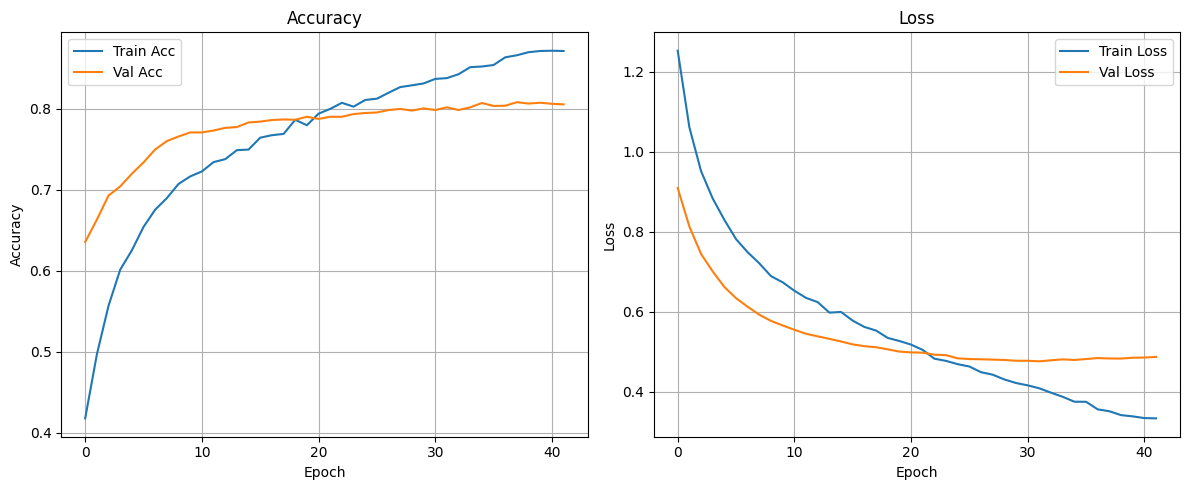


--- Model Training Step Finished ---


In [25]:
# Step 8: Model Training
# ============================================================
print("\n--- Step 8: Training Model (3 Classes) ---")
model_weights_filename = f"multimodal_FER3cls_{'attn' if USE_ATTENTION_FUSION else 'concat'}_best.weights.h5"
history = None
# Define Training Hyperparameters (Example)
LEARNING_RATE = 5e-5
REDUCE_LR_PATIENCE = 5
EARLY_STOP_PATIENCE = 10
EPOCHS = 100
BATCH_SIZE = 32

if model_built_flag and data_loaded_successfully and validation_set_available:
    print("Preparing training...")
    mc = ModelCheckpoint(filepath=model_weights_filename, save_weights_only=True, monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
    es = EarlyStopping(monitor='val_loss', patience=EARLY_STOP_PATIENCE, mode='min', restore_best_weights=True, verbose=1, start_from_epoch=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=REDUCE_LR_PATIENCE, min_lr=1e-7, verbose=1)
    callbacks_list = [mc, es, reduce_lr]
    try: optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE); print(f"Using Adam optimizer with LR={LEARNING_RATE}.")
    except AttributeError: optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE); print(f"AdamW not found. Using Adam optimizer with LR={LEARNING_RATE}.")
    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy']); print("Model re-compiled with specified learning rate.")
    train_inputs = [X_train_vid, X_train_aud, X_train_eeg]; val_inputs = [X_val_vid, X_val_aud, X_val_eeg]
    print("\nCalculating class weights..."); class_weights_dict = None
    try:
        y_train_indices = np.argmax(y_train, axis=1); unique_classes_train = np.unique(y_train_indices)
        if len(unique_classes_train) == NUM_CLASSES:
            class_weights_array = compute_class_weight('balanced', classes=np.arange(NUM_CLASSES), y=y_train_indices)
            class_weights_dict = dict(enumerate(class_weights_array)); print("Using Class Weights:"); [print(f"  Class {i} ({CLASS_LABELS.get(i,'?')}) - W: {w:.3f}") for i, w in class_weights_dict.items()]
        else: print(f"WARN: Only {len(unique_classes_train)}/{NUM_CLASSES} classes in train split. Not using class weights.");
    except Exception as e: print(f"WARN: Class weight calculation failed ({e}). Not using class weights.");
    print(f"\nInitiating training (Max Epochs: {EPOCHS}, Batch: {BATCH_SIZE}, LR: {LEARNING_RATE}, ES Patience: {EARLY_STOP_PATIENCE}, LR Patience: {REDUCE_LR_PATIENCE})...")
    try:
        start_time = time.time();
        history = model.fit( train_inputs, y_train, validation_data=(val_inputs, y_val), epochs=EPOCHS, batch_size=BATCH_SIZE, class_weight=class_weights_dict, callbacks=callbacks_list, verbose=1 )
        end_time = time.time(); print(f"\n--- Training Finished --- Time: {end_time - start_time:.2f}s");
        weights_saved = os.path.exists(model_weights_filename); es_restored = es.stopped_epoch > 0 and hasattr(es, 'best_weights') and es.best_weights is not None;
        if es_restored: print(f"EarlyStopping restored weights from epoch {es.best_epoch + 1} (best val_loss: {es.best:.4f})")
        if weights_saved: print(f"ModelCheckpoint saved best weights (val_acc) to '{model_weights_filename}'.")
        elif es_restored: print(f"Warning: MC did not save weights, but ES restored.")
        else: print(f"Warning: Neither ES restored nor MC saved weights.")
    except Exception as e: print(f"\n--- Training FAILED --- Error: {e}"); traceback.print_exc(); history = None
    # Plot History
    if history and hasattr(history, 'history') and history.history:
        required_keys = ['accuracy', 'val_accuracy', 'loss', 'val_loss']
        if all(key in history.history for key in required_keys):
            try:
                print("\nPlotting training history..."); plt.figure(figsize=(12, 5));
                plt.subplot(1, 2, 1); plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc'); plt.title('Accuracy'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.grid(True);
                plt.subplot(1, 2, 2); plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss'); plt.title('Loss'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(True);
                plt.tight_layout(); plt.show()
            except Exception as plot_e: print(f"Plot history failed: {plot_e}")
        else: print("Skipping history plot: Missing keys.")
elif not model_built_flag: print("Skipping Training: Model not built.")
elif not data_loaded_successfully: print("Skipping Training: Data not loaded.")
elif not validation_set_available: print("Skipping Training: Validation set not available.")
print("\n--- Model Training Step Finished ---")


--- Step 8.5: Evaluating Model (3 Classes) ---
Preparing validation data for evaluation...

Checking model weights state for evaluation...
 Evaluating using weights restored by EarlyStopping (best val_loss).

Calculating overall loss/accuracy on validation set...
  Validation Loss: 0.4760, Validation Accuracy: 80.17%

Generating predictions & reports for validation set...

--- Classification Report (Validation Set) ---
              precision    recall  f1-score   support

       happy       0.84      0.86      0.85      1000
         sad       0.83      0.79      0.81      1000
     neutral       0.74      0.75      0.75      1000

    accuracy                           0.80      3000
   macro avg       0.80      0.80      0.80      3000
weighted avg       0.80      0.80      0.80      3000


--- Confusion Matrix (Validation Set) ---
True Labels (Rows) vs Predicted Labels (Columns):
 [[861  33 106]
 [ 49 792 159]
 [117 131 752]]

Plotting Confusion Matrix...


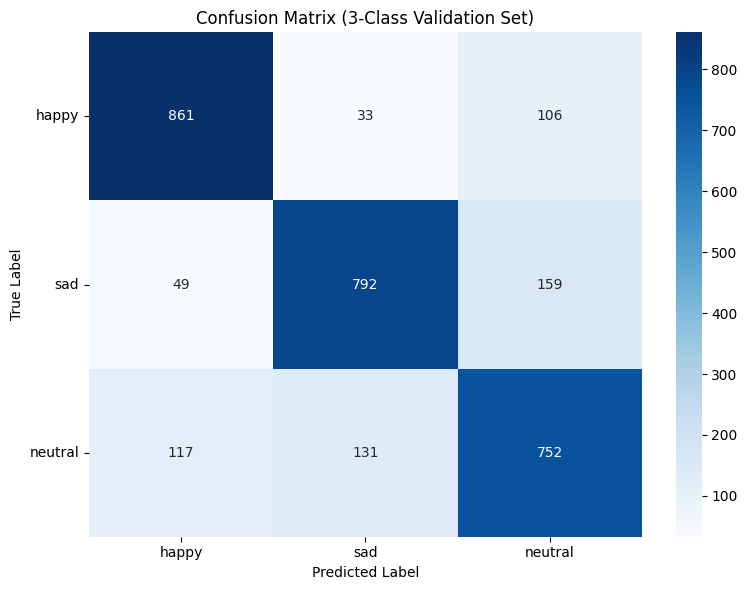


--- Analysis of Misclassifications (Illustrative) ---
Example: Analyzing 'Sad' (1) vs 'Neutral' (2) Confusion:
  - True 'Sad' misclassified as 'Neutral': 159 (15.9%)
  - True 'Neutral' misclassified as 'Sad': 131 (13.1%)
  - Potential Reasons: Visual/Acoustic Subtlety, Merged Class Overlap, Data Imbalance, EEG Heuristics.

--- Model Evaluation Finished ---


In [26]:
# Step 8.5: Model Evaluation
# ============================================================
print("\n--- Step 8.5: Evaluating Model (3 Classes) ---")
if model_built_flag and data_loaded_successfully and validation_set_available:
    print("Preparing validation data for evaluation...")
    val_inputs = [X_val_vid, X_val_aud, X_val_eeg]; val_true_labels_int = np.argmax(y_val, axis=1)
    try:
        print("\nChecking model weights state for evaluation...")
        weights_loaded = False; es_restored = 'es' in globals() and es.stopped_epoch > 0 and hasattr(es, 'best_weights') and es.best_weights is not None
        if es_restored: print(" Evaluating using weights restored by EarlyStopping (best val_loss)."); weights_loaded = True
        elif os.path.exists(model_weights_filename):
             try: print(f" Loading best weights from {model_weights_filename}"); model.load_weights(model_weights_filename); print(" Successfully loaded best weights (best val_accuracy)."); weights_loaded = True
             except Exception as e: print(f" WARNING: Failed to load weights from {model_weights_filename}: {e}. Evaluating with current state.")
        else: print(" WARNING: No weights file found and ES did not restore. Evaluating with model's state at end of training.")
        print("\nCalculating overall loss/accuracy on validation set...")
        eval_results = model.evaluate(val_inputs, y_val, batch_size=BATCH_SIZE, verbose=0); print(f"  Validation Loss: {eval_results[0]:.4f}, Validation Accuracy: {eval_results[1] * 100:.2f}%");
        print("\nGenerating predictions & reports for validation set...")
        preds_proba = model.predict(val_inputs, batch_size=BATCH_SIZE, verbose=0); y_pred_classes = np.argmax(preds_proba, axis=1)
        target_names = [CLASS_LABELS.get(i, f"Class_{i}") for i in range(NUM_CLASSES)]; report_labels = np.arange(NUM_CLASSES)
        print("\n--- Classification Report (Validation Set) ---")
        try: report = classification_report(val_true_labels_int, y_pred_classes, labels=report_labels, target_names=target_names, zero_division=0); print(report)
        except Exception as e: print(f"Error generating classification report: {e}")
        print("\n--- Confusion Matrix (Validation Set) ---")
        try:
            cm = confusion_matrix(val_true_labels_int, y_pred_classes, labels=report_labels); print("True Labels (Rows) vs Predicted Labels (Columns):\n", cm);
            print("\nPlotting Confusion Matrix..."); plt.figure(figsize=(8, 6));
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names);
            plt.xlabel('Predicted Label'); plt.ylabel('True Label'); plt.title(f'Confusion Matrix ({NUM_CLASSES}-Class Validation Set)'); plt.xticks(rotation=0); plt.yticks(rotation=0); plt.tight_layout(); plt.show()
        except Exception as e: print(f"Error generating/plotting confusion matrix: {e}")
        # --- Misclassification Analysis ---
        print("\n--- Analysis of Misclassifications (Illustrative) ---")
        if 'cm' in locals() and isinstance(cm, np.ndarray) and cm.shape == (NUM_CLASSES, NUM_CLASSES):
             sad_true_idx, neutral_true_idx = 1, 2; sad_pred_idx, neutral_pred_idx = 1, 2;
             sad_as_neutral = cm[sad_true_idx, neutral_pred_idx]; neutral_as_sad = cm[neutral_true_idx, sad_pred_idx];
             total_true_sad = np.sum(cm[sad_true_idx, :]); total_true_neutral = np.sum(cm[neutral_true_idx, :]);
             print(f"Example: Analyzing 'Sad' (1) vs 'Neutral' (2) Confusion:")
             if total_true_sad > 0: print(f"  - True 'Sad' misclassified as 'Neutral': {sad_as_neutral} ({sad_as_neutral/total_true_sad*100:.1f}%)")
             else: print("  - No 'Sad' samples in validation set.")
             if total_true_neutral > 0: print(f"  - True 'Neutral' misclassified as 'Sad': {neutral_as_sad} ({neutral_as_sad/total_true_neutral*100:.1f}%)")
             else: print("  - No 'Neutral' samples in validation set.")
             if sad_as_neutral > 0 or neutral_as_sad > 0:
                 print("  - Potential Reasons: Visual/Acoustic Subtlety, Merged Class Overlap, Data Imbalance, EEG Heuristics.")
             else: print("  - Little confusion observed between 'Sad' and 'Neutral'.")
        else: print("  - Could not perform detailed misclassification analysis (CM unavailable/invalid).")
    except Exception as e: print(f"\nAn error occurred during model evaluation: {e}"); traceback.print_exc()
else: print("Skipping model evaluation (Model/Data/ValidationSet not ready).")
print("\n--- Model Evaluation Finished ---")

In [27]:
# Step 9: Remedy Generation Function (Adapted for 3 Classes)
# ============================================================
print("\n--- Step 9: Defining Remedy Generation Function (3 Classes) ---")
def generate_remedy(emotion_label):
    """Generates simple suggestions for Happy, Sad, Neutral."""
    global text_generator; emotion_label_lower = emotion_label.lower();
    if emotion_label_lower == "happy": return "Great to see you're happy! Keep enjoying the moment."
    if emotion_label_lower == "neutral": return "Feeling neutral is okay. Perhaps take a moment for quiet reflection."
    if emotion_label_lower == "sad": prompt = "I feel sad. Suggest one small, comforting action I can take right now:"
    else: prompt = f"I am feeling {emotion_label}. Suggest one simple positive action:"
    if not HUGGINGFACE_AVAILABLE or text_generator is None: return "It's okay to feel sad. Try some deep breaths." if emotion_label_lower == "sad" else "Acknowledge your feelings."
    print(f"  Generating remedy for '{emotion_label}' using prompt: '{prompt}'")
    try:
        response = text_generator(prompt, max_new_tokens=40, num_return_sequences=1, pad_token_id=text_generator.tokenizer.eos_token_id, eos_token_id=text_generator.tokenizer.eos_token_id, num_beams=3, early_stopping=True, truncation=True)
        generated_text = response[0]['generated_text']; suggestion_text = generated_text
        if generated_text.startswith(prompt): suggestion_text = generated_text[len(prompt):].strip()
        suggestion_text = re.sub(r'\s+', ' ', suggestion_text).strip().replace('"', ''); first_suggestion = suggestion_text.split('.')[0]
        if len(first_suggestion) < 5: first_suggestion = suggestion_text.split('\n')[0]
        max_len = 150; final_suggestion = first_suggestion.strip()[:max_len] + ('...' if len(first_suggestion) > max_len else '')
        return final_suggestion if final_suggestion else "Could not generate a clear suggestion."
    except Exception as e: print(f"Remedy Gen Error (Text Generation): {e}"); return "Suggestion generation failed."
print("Remedy generation function (3-class) defined.")



--- Step 9: Defining Remedy Generation Function (3 Classes) ---
Remedy generation function (3-class) defined.


In [29]:
# Step 10: Colab Live Capture & Prediction Functions (Adapted for 3 Classes)
# ============================================================
print("\n--- Step 10: Defining Live Capture & Prediction Functions (3 Classes) ---")

# --- JavaScript Generation Functions ---

def js_capture_photo(quality=0.8):
    """Generates JS code to capture a webcam photo in Colab."""
    js_code = f'''
    async function capturePhoto(quality) {{
      // Create elements
      const div = document.createElement('div');
      const captureButton = document.createElement('button');
      captureButton.textContent = 'Capture Video Frame';
      div.appendChild(captureButton);
      const video = document.createElement('video');
      video.style.display = 'block';

      // Get webcam stream
      const stream = await navigator.mediaDevices.getUserMedia({{ video: true }});
      document.body.appendChild(div); // Add elements to the output area
      div.appendChild(video);
      video.srcObject = stream;
      await video.play();

      // Resize Colab output frame to fit video
      google.colab.output.setIframeHeight(document.documentElement.scrollHeight, true);

      // Wait for button click
      await new Promise((resolve) => captureButton.onclick = resolve);

      // Draw frame to canvas
      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      // Stop stream and remove elements
      stream.getVideoTracks()[0].stop();
      div.remove();

      // Return image data as JPEG data URL
      return canvas.toDataURL('image/jpeg', quality);
    }}
    '''
    if IN_COLAB:
        display(Javascript(js_code))
        # Execute JS and return result
        data = output.eval_js(f'capturePhoto({quality})')
        return data
    else:
        print("Live capture only available in Colab.")
        return None

def js_record_audio(duration_sec=AUDIO_RECORD_DURATION_SEC, sample_rate=AUDIO_SAMPLE_RATE):
    """Generates JS code to record audio in Colab and send data via callback."""
    if not IN_COLAB:
        print("Live audio only available in Colab.")
        return None
    register_audio_callback() # Ensure callback is registered
    # JavaScript code using AudioContext for resampling and WAV encoding
    js_code=f"""
    async function recordAudioAndCallback(duration, targetSampleRate) {{
        const div = document.createElement('div');
        const startButton = document.createElement('button');
        startButton.textContent = 'Start Recording ({duration_sec}s)';
        div.appendChild(startButton);
        document.body.appendChild(div);

        await new Promise(resolve => startButton.onclick = resolve); // Wait for click
        startButton.textContent = 'Recording...'; startButton.disabled = true;

        // Notify Python backend
        google.colab.kernel.invokeFunction('notebook.audio_callback', ['RECORDING_STARTED'], {{}});

        try {{
            const stream = await navigator.mediaDevices.getUserMedia({{ audio: true }});
            const audioContext = new (window.AudioContext || window.webkitAudioContext)({{ sampleRate: targetSampleRate }});
            const source = audioContext.createMediaStreamSource(stream);
            const processor = audioContext.createScriptProcessor(4096, 1, 1); // Buffer size, input/output channels

            let audioData = []; // Array to store PCM data chunks
            processor.onaudioprocess = (e) => {{
                const inputData = e.inputBuffer.getChannelData(0);
                audioData.push(new Float32Array(inputData)); // Store chunk
            }};

            source.connect(processor);
            processor.connect(audioContext.destination); // Necessary to start processing

            // Record for specified duration
            await new Promise(resolve => setTimeout(resolve, duration * 1000));

            // Stop recording & cleanup JS side
            processor.disconnect(); source.disconnect();
            stream.getAudioTracks()[0].stop(); audioContext.close();
            div.remove(); // Remove button

            // Combine PCM chunks
            const totalLength = audioData.reduce((sum, buf) => sum + buf.length, 0);
            const combinedPCM = new Float32Array(totalLength);
            let offset = 0;
            for (const buf of audioData) {{ combinedPCM.set(buf, offset); offset += buf.length; }}

            // Encode PCM to WAV blob
            const wavBuffer = encodeWAV(combinedPCM, targetSampleRate);
            const blob = new Blob([wavBuffer], {{ type: 'audio/wav' }});

            // Convert Blob to Base64 Data URL and send to Python
            const reader = new FileReader();
            reader.onloadend = () => {{ google.colab.kernel.invokeFunction('notebook.audio_callback', [reader.result], {{}}); }};
            reader.readAsDataURL(blob);

        }} catch (err) {{
            console.error("Audio recording/processing failed:", err);
            google.colab.kernel.invokeFunction('notebook.audio_callback', ['RECORDING_ERROR:' + err.message], {{}});
            if(div) div.remove(); // Cleanup button on error
        }}
    }}

    // Helper functions for WAV encoding (included within the JS string)
    function encodeWAV(samples, sampleRate) {{
        const buffer = new ArrayBuffer(44 + samples.length * 2); const view = new DataView(buffer);
        writeString(view, 0, 'RIFF'); view.setUint32(4, 36 + samples.length * 2, true); writeString(view, 8, 'WAVE');
        writeString(view, 12, 'fmt '); view.setUint32(16, 16, true); view.setUint16(20, 1, true); view.setUint16(22, 1, true); // Mono, PCM
        view.setUint32(24, sampleRate, true); view.setUint32(28, sampleRate * 2, true); view.setUint16(32, 2, true); view.setUint16(34, 16, true); // 16-bit
        writeString(view, 36, 'data'); view.setUint32(40, samples.length * 2, true);
        floatTo16BitPCM(view, 44, samples); return buffer;
    }}
    function writeString(view, offset, string) {{ for (let i = 0; i < string.length; i++) {{ view.setUint8(offset + i, string.charCodeAt(i)); }} }}
    function floatTo16BitPCM(output, offset, input) {{ for (let i = 0; i < input.length; i++, offset += 2) {{ const s = Math.max(-1, Math.min(1, input[i])); output.setInt16(offset, s < 0 ? s * 0x8000 : s * 0x7FFF, true); }} }}
    """
    js = Javascript(js_code)
    display(js) # Display the button and trigger JS execution
    print(f"Click the 'Start Recording ({duration_sec}s)' button that appears above...")
    # Start the JS function execution
    output.eval_js(f'recordAudioAndCallback({duration_sec}, {sample_rate})')


# --- Python Callback & Registration ---

colab_audio_data_buffer = None # Global variable to hold audio data from JS

def _audio_callback_colab(data_url_or_status):
    """Internal callback function invoked by Colab kernel from JS."""
    global colab_audio_data_buffer
    if isinstance(data_url_or_status, str):
        if data_url_or_status.startswith("data:audio/wav;base64,"): # Expecting WAV data URL
            colab_audio_data_buffer = data_url_or_status
            print("  Audio data received by callback.")
        elif data_url_or_status == "RECORDING_STARTED":
            print("  Audio recording started (JS confirmation).")
        elif data_url_or_status.startswith("RECORDING_ERROR"):
             print(f"  Audio Error from JS: {data_url_or_status}")
             colab_audio_data_buffer = "ERROR" # Signal error state
        else:
             # print(f"  Audio callback received unexpected message: {data_url_or_status}")
             colab_audio_data_buffer = None # Reset on other messages
    else:
         # print("  Audio callback received non-string data.")
         colab_audio_data_buffer = None # Reset

def register_audio_callback():
    """Registers the Python callback function in Colab's backend if not already done."""
    if IN_COLAB:
        try:
            # Attempt to register the callback function under the name 'notebook.audio_callback'
            output.register_callback('notebook.audio_callback', _audio_callback_colab)
            # print("Audio callback 'notebook.audio_callback' registered.") # Optional confirmation
        except Exception as e:
            # Ignore if already registered in the same session (common occurrence)
            pass

# --- Python Capture Wrapper Functions ---

def capture_video_frame_colab():
    """
    Initiates video capture in Colab, waits for user interaction,
    decodes the result, and returns an OpenCV frame (BGR format).

    Returns:
        np.ndarray | None: Captured frame as BGR NumPy array, or None on failure/cancellation.
    """
    if not IN_COLAB:
        print("Video capture only available in Google Colab.")
        return None
    try:
        print("Waiting for user to click 'Capture Video Frame' button...")
        data_url = js_capture_photo() # Execute JS and get data URL

        if not data_url:
            print("ERROR: Video capture failed or was cancelled by user (no data URL returned).")
            return None

        # Decode the Base64 encoded JPEG data
        header, encoded = data_url.split(",", 1)
        binary_data = b64decode(encoded)

        # Convert binary data to PIL Image, then to OpenCV BGR format
        image_pil = PILImage.open(io.BytesIO(binary_data))
        frame_bgr = cv2.cvtColor(np.array(image_pil), cv2.COLOR_RGB2BGR) # PIL is RGB, OpenCV uses BGR

        print("Video frame captured successfully.")
        return frame_bgr

    except Exception as e:
        print(f"ERROR during video frame capture or processing: {e}")
        traceback.print_exc()
        return None

def capture_audio_data_colab(duration_sec=AUDIO_RECORD_DURATION_SEC):
    """
    Initiates audio recording in Colab, waits for data via callback,
    and returns the audio data as a BytesIO buffer.

    Args:
        duration_sec (int): Duration of the audio recording.

    Returns:
        io.BytesIO | None: Captured audio data in WAV format within a BytesIO buffer,
                           or None on failure/timeout.
    """
    if not IN_COLAB:
        print("Audio capture only available in Google Colab.")
        return None

    global colab_audio_data_buffer
    colab_audio_data_buffer = None # Reset buffer before starting new capture

    try:
        # Trigger the JavaScript recording process
        js_record_audio(duration_sec)

        # Wait for the audio data to arrive via the callback, with a timeout
        timeout_seconds = duration_sec + 25 # Allow generous time for processing/transfer
        print(f"Waiting up to ~{timeout_seconds} seconds for audio data after clicking start...")
        start_wait_time = time.time()

        while colab_audio_data_buffer is None and (time.time() - start_wait_time) < timeout_seconds:
            time.sleep(0.5) # Poll the buffer status

        # Check the final state of the buffer
        if isinstance(colab_audio_data_buffer, str) and colab_audio_data_buffer.startswith("data:audio/wav;base64,"):
            print("Audio captured successfully.")
            try:
                # Decode base64 audio data URL
                header, encoded = colab_audio_data_buffer.split(",", 1)
                binary_data = b64decode(encoded)
                # Return as a BytesIO buffer, ready for librosa/soundfile
                return io.BytesIO(binary_data)
            except Exception as decode_e:
                print(f"ERROR: Failed to decode received audio data: {decode_e}")
                return None
        elif colab_audio_data_buffer == "ERROR":
             print("ERROR: Audio recording failed in browser (check console for details).")
             return None
        elif colab_audio_data_buffer is None: # Timeout occurred
             print("ERROR: Audio capture timed out. No data received from callback.")
             return None
        else: # Some other unexpected message/state
            print(f"ERROR: Unexpected state/data in audio buffer after wait: {colab_audio_data_buffer}")
            return None

    except Exception as e:
        print(f"ERROR during audio capture initiation process: {e}")
        traceback.print_exc()
        return None
    finally:
        colab_audio_data_buffer = None # Ensure buffer is cleared


# --- Utility Functions ---

def load_sample_bonn_eeg(bonn_path, category='Z'):
    """
    Loads a single random EEG signal file from a specified Bonn category.
    Handles case-insensitive file extensions (.txt/.TXT).

    Args:
        bonn_path (str): Path to the base Bonn EEG dataset directory.
        category (str): The category folder (e.g., 'Z', 'O', 'S') to load from.

    Returns:
        np.ndarray | None: Loaded EEG signal as a 1D NumPy array, or None on failure.
    """
    # Check if data was verified as present in Step 1.6
    if not bonn_data_present:
        print(f"ERROR: Bonn data was not verified as present at {bonn_path}. Cannot load sample.")
        return None

    cat_path = os.path.join(bonn_path, category)
    if not os.path.isdir(cat_path):
        print(f"ERROR: EEG Category directory missing: {cat_path}")
        return None

    try:
        # Find both .txt and .TXT files
        files = glob.glob(os.path.join(cat_path, "*.txt")) + glob.glob(os.path.join(cat_path, "*.TXT"))
        if not files:
            print(f"ERROR: No EEG .txt or .TXT files found in {cat_path}")
            return None

        # Select and load a random file
        random_eeg_file = random.choice(files)
        signal = pd.read_csv(random_eeg_file, header=None).values.flatten()

        # Validate signal length
        if len(signal) == EEG_SIGNAL_LENGTH:
            print(f"Loaded sample EEG: {os.path.basename(random_eeg_file)} from Category {category}")
            return signal
        else:
            print(f"ERROR: Loaded EEG signal {os.path.basename(random_eeg_file)} has incorrect length: {len(signal)} (expected {EEG_SIGNAL_LENGTH})")
            return None

    except pd.errors.EmptyDataError:
        print(f"ERROR: Sample EEG file is empty: {os.path.basename(random_eeg_file)}")
        return None
    except Exception as e:
        print(f"Error loading sample EEG file {random_eeg_file if 'random_eeg_file' in locals() else 'N/A'}: {e}")
        return None

def draw_text(img, text, org, font_scale=0.5, color=(255, 255, 255), thickness=1, line_spacing=1.3):
    """
    Draws multi-line text with a black background rectangle onto an image.

    Args:
        img (np.ndarray): Image to draw on (modified in-place).
        text (str): Text to draw (can contain newline characters '\n').
        org (tuple): Bottom-left corner of the first line of text (x, y).
        font_scale (float): Font scale factor.
        color (tuple): Text color (B, G, R).
        thickness (int): Text thickness.
        line_spacing (float): Multiplier for vertical spacing between lines.

    Returns:
        int: The y-coordinate below the last line of text drawn.
    """
    font = cv2.FONT_HERSHEY_SIMPLEX
    lines = text.split('\n')
    # Get text size of the first line to estimate height and baseline
    (text_width, text_height), baseline = cv2.getTextSize(lines[0], font, font_scale, thickness)
    y = org[1] # Initial y position for the first line's baseline

    for i, line in enumerate(lines):
        if not line.strip(): continue # Skip empty lines

        (line_width, line_height), line_baseline = cv2.getTextSize(line, font, font_scale, thickness)
        # Calculate y position for the baseline of the current line
        # Uses estimated height from first line for consistent spacing
        line_y_baseline = y + i * int(text_height * line_spacing)

        # Calculate background rectangle coordinates
        # Top-left corner: (org[0] - padding, line_y_baseline - text_height - baseline + 1 - padding)
        # Bottom-right corner: (org[0] + line_width + padding, line_y_baseline + baseline + padding)
        bg_x1 = org[0] - 2
        bg_y1 = line_y_baseline - text_height - baseline + 1 - 2 # Use first line's text_height/baseline
        bg_x2 = org[0] + line_width + 2
        bg_y2 = line_y_baseline + baseline + 2

        # Draw black background rectangle (filled)
        cv2.rectangle(img, (bg_x1, bg_y1), (bg_x2, bg_y2), (0, 0, 0), -1)

        # Draw the text line itself
        cv2.putText(img, line, (org[0], line_y_baseline), font, font_scale, color, thickness, cv2.LINE_AA)

    # Return the approximate y-coordinate below the last line drawn
    return y + len(lines) * int(text_height * line_spacing)


# --- Load Face Detection Cascade ---
print("\nLoading Haar Cascade for face detection...")
face_cascade = None
try:
    # Find OpenCV's data directory reliably
    cv2_base_dir = os.path.dirname(os.path.abspath(cv2.__file__))
    haar_path = os.path.join(cv2_base_dir, 'data', 'haarcascade_frontalface_default.xml')

    if os.path.exists(haar_path):
        face_cascade = cv2.CascadeClassifier(haar_path)
        if face_cascade.empty():
            print(f"WARN: Failed loading Haar Cascade from {haar_path} (resulted in empty classifier).")
            face_cascade = None # Ensure it's None if loading fails
        else:
            print("Haar Cascade face detector loaded successfully.")
    else:
        print(f"WARN: Haar Cascade file not found at the expected location: {haar_path}")
        print("         Face detection in live prediction will not work.")
        face_cascade = None # Ensure it's None if file missing

except Exception as e:
    print(f"ERROR loading Haar Cascade classifier: {e}")
    face_cascade = None # Ensure it's None on error


# --- Main Live Prediction Runner (Adapted for 3 classes) ---
def run_live_prediction_colab_visual_3class(model_obj, bonn_path, face_cascade_obj):
    """
    Runs one cycle of live prediction in Colab for the 3-class model:
    1. Checks prerequisites.
    2. Loads a static sample EEG context.
    3. Captures video frame via webcam.
    4. Captures audio snippet via microphone.
    5. Detects the largest face in the video frame.
    6. Extracts features (Video ROI, Audio snippet, static EEG).
    7. Predicts emotion (Happy, Sad, Neutral) using the multimodal model.
    8. Generates a simple remedy suggestion based on the prediction.
    9. Displays the captured frame with bounding box, prediction, and remedy overlay.
    """
    print("\n" + "▶️" * 3 + " Starting Live Prediction Cycle (3 Classes) " + "▶️" * 3)

    # --- 1. Prerequisite Checks ---
    print("Checking prerequisites for live prediction...")
    if not IN_COLAB: print("❌ ERROR: Live capture requires Colab environment."); return
    if model_obj is None: print("❌ ERROR: Model object is not available."); return
    if face_cascade_obj is None: print("❌ ERROR: Face detection cascade is not loaded."); return
    if not bonn_data_present: print("❌ ERROR: Bonn EEG data not verified as present (check Step 1.6)."); return
    print("✅ Prerequisites OK.")

    # --- 2. Load Static EEG Context ---
    # LIMITATION: Uses a fixed sample EEG, not real-time user EEG.
    print("\nLoading static sample EEG context (using Category 'Z')...")
    eeg_raw_signal = load_sample_bonn_eeg(bonn_path, category='Z') # Try loading from healthy/eyes open
    if eeg_raw_signal is None:
        print("WARNING: Failed to load sample EEG signal. Using ZERO EEG features for this cycle.")
        eeg_features = ZERO_EEG_FEAT
    else:
        eeg_features = process_bonn_eeg_signal(eeg_raw_signal)
        if not np.any(eeg_features): # Check if processing resulted in zero vector
             print("WARNING: EEG signal processing failed for sample. Using ZERO EEG features.")
             eeg_features = ZERO_EEG_FEAT
        else:
             print("✅ Static EEG features processed successfully.")
    # Prepare EEG input batch (batch size of 1)
    eeg_input_batch = np.expand_dims(eeg_features, axis=0).astype(np.float32)

    # --- 3. Capture Video Frame ---
    print("\nInitiating video frame capture...")
    video_frame = capture_video_frame_colab()
    if video_frame is None:
        print("❌ Aborting cycle: Video capture failed or was cancelled.")
        return
    display_frame = video_frame.copy() # Keep a copy for drawing overlays
    print("✅ Video frame captured.")

    # --- 4. Capture Audio Snippet ---
    print("\nInitiating audio snippet capture...")
    audio_buffer = capture_audio_data_colab(duration_sec=AUDIO_RECORD_DURATION_SEC)
    aud_features = ZERO_AUDIO_FEAT # Default to zero
    if audio_buffer is None:
        print("WARNING: Audio capture failed or timed out. Using ZERO audio features.")
    else:
        print("Processing captured audio...")
        aud_features = extract_audio_features(audio_buffer, augment=False) # No augmentation for live prediction
        if not np.any(aud_features):
            print("WARNING: Audio feature extraction failed. Using ZERO audio features.")
            aud_features = ZERO_AUDIO_FEAT # Ensure zero vector on failure
        else:
            print("✅ Audio features processed successfully.")
    # Prepare Audio input batch
    audio_input_batch = np.expand_dims(aud_features, axis=0).astype(np.float32)

    # --- 5. Face Detection ---
    print("\nDetecting face in the video frame...")
    gray_frame = cv2.cvtColor(video_frame, cv2.COLOR_BGR2GRAY)
    # Detect faces using the loaded cascade
    faces = face_cascade_obj.detectMultiScale(
        gray_frame,
        scaleFactor=1.1,    # How much image size is reduced at each scale
        minNeighbors=5,     # How many neighbors each candidate rectangle should have
        minSize=(40, 40)    # Minimum possible object size
    )
    print(f"Found {len(faces)} face(s).")

    # --- 6. Feature Extraction (Video ROI) & Prediction ---
    vid_features = ZERO_VIDEO_FEAT # Default to zero
    predicted_emotion = "No face detected" # Default message
    confidence = 0.0
    remedy_text = "N/A"
    face_coords = None # Store coordinates of the detected face

    if len(faces) > 0:
        # Select the largest face based on area (w * h)
        faces = sorted(faces, key=lambda f: f[2] * f[3], reverse=True)
        x, y, w, h = faces[0] # Coordinates of the largest face
        face_coords = (x, y, w, h)

        # Draw bounding box on the display frame (green color)
        cv2.rectangle(display_frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        # Extract the Region of Interest (ROI) - the detected face
        face_roi = video_frame[y:y + h, x:x + w]

        if face_roi.size > 0:
            print("Extracting features from detected face ROI...")
            # Extract features from the ROI (pass the BGR ROI)
            vid_features = extract_video_features(face_roi, augment=False)

            if not np.any(vid_features): # Check if extraction failed
                print("WARNING: Video feature extraction failed for face ROI.")
                predicted_emotion = "Video Error" # Update status message
                vid_features = ZERO_VIDEO_FEAT # Ensure zero vector
            else:
                print("✅ Video features extracted from face.")
        else:
            print("WARNING: Face ROI is empty (invalid coordinates?).")
            predicted_emotion = "ROI Error" # Update status

    # Prepare Video input batch
    video_input_batch = np.expand_dims(vid_features, axis=0).astype(np.float32)

    # --- 7. Predict Emotion (only if valid video features exist) ---
    if np.any(vid_features): # Check if video features are not the zero vector
        print("\nPredicting emotion using the multimodal model...")
        # Prepare model inputs in the correct order defined by the model: [Video, Audio, EEG]
        model_inputs = [video_input_batch, audio_input_batch, eeg_input_batch]
        try:
            # Get probability predictions from the model
            probabilities = model_obj.predict(model_inputs, verbose=0)[0] # Get first (only) batch result

            # Find the class index with the highest probability
            predicted_index = np.argmax(probabilities)
            confidence = np.max(probabilities) * 100 # Confidence score percentage
            # Map index to 3-class label
            predicted_emotion = CLASS_LABELS.get(predicted_index, f"Unknown ({predicted_index})")

            print(f"---> Predicted Emotion: {predicted_emotion} (Confidence: {confidence:.1f}%)")

            # --- 8. Generate Remedy ---
            print("Generating remedy suggestion...")
            remedy_text = generate_remedy(predicted_emotion) # Use the 3-class function
            print(f"---> Suggestion: {remedy_text}")

            # Add prediction text near the bounding box on the display frame
            if face_coords:
                pred_text = f"{predicted_emotion} ({confidence:.0f}%)"
                # Position text above the box, or below if box is near the top edge
                text_y = y - 10 if y > 20 else y + h + 15
                # Use draw_text helper for background
                draw_text(display_frame, pred_text, (x, text_y), font_scale=0.6, color=(0, 255, 0), thickness=2)

        except Exception as e:
            print(f"ERROR during model prediction or remedy generation: {e}")
            traceback.print_exc()
            predicted_emotion = "Prediction Error" # Update status on error
            remedy_text = "N/A"
            confidence = 0.0
    else:
        # Handle cases where no face was detected or video features failed earlier
        print(f"Skipping prediction ({predicted_emotion}).")


    # --- 9. Display Results ---
    print("\n--- 📊 Displaying Results ---")
    # Define text properties for overlay info
    org_info = (10, 30) # Top-left corner for general info text
    color_info = (0, 255, 255) # Yellow color for info
    font_scale_info = 0.6
    thickness_info = 1
    line_spacing_info = 1.3

    # Display predicted emotion and confidence
    info_text = f"Predicted: {predicted_emotion} ({confidence:.1f}%)"
    last_y_pos = draw_text(display_frame, info_text, org_info, font_scale_info, color_info, thickness_info, line_spacing_info)

    # Display remedy suggestion if available
    if remedy_text != "N/A":
        org_remedy_title = (org_info[0], last_y_pos + 5) # Position below info text
        org_remedy_text = (org_info[0] + 5, org_remedy_title[1] + int(15 * line_spacing_info)) # Indent remedy text
        color_remedy = (255, 255, 255) # White color for remedy
        font_scale_remedy = 0.55

        draw_text(display_frame, "Suggestion:", org_remedy_title, font_scale_info * 0.9, color_info, thickness_info, line_spacing_info)
        # Basic text wrapping for display
        wrapped_remedy = ""; max_line_len = 50; current_line = ""
        for word in remedy_text.split():
            test_line = current_line + (" " if current_line else "") + word
            # Check width roughly (better wrapping needs font metrics)
            if len(test_line) <= max_line_len:
                current_line = test_line
            else:
                wrapped_remedy += current_line + "\n"
                current_line = word
        wrapped_remedy += current_line # Add the last line

        draw_text(display_frame, wrapped_remedy, org_remedy_text, font_scale_remedy, color_remedy, thickness_info, line_spacing_info)

    # Display the final frame in Colab output
    if IN_COLAB:
        # Convert final frame from OpenCV BGR to RGB for PIL/display
        display_frame_rgb = cv2.cvtColor(display_frame, cv2.COLOR_BGR2RGB)
        display(PILImage.fromarray(display_frame_rgb))
    else:
        # Basic display if running outside Colab (requires GUI backend)
        try: cv2.imshow("Live Prediction (3 Class)", display_frame); cv2.waitKey(1);
        except Exception as e: print(f"Could not display frame locally: {e}")

    print("\n" + "✅" * 3 + " Live Prediction Cycle Complete " + "✅" * 3)

# --- Register Colab Audio Callback Once ---
# Needs to be done after the callback function is defined
if IN_COLAB: register_audio_callback()

print("\nLive capture and prediction functions (3-class) defined.")


--- Step 10: Defining Live Capture & Prediction Functions (3 Classes) ---

Loading Haar Cascade for face detection...
Haar Cascade face detector loaded successfully.

Live capture and prediction functions (3-class) defined.



=============== Step 11: Running Main Execution Block (3 Classes) ===============

Checking prerequisites for live prediction execution...
  - Model Ready: True, Cascade Ready: True, Bonn Data OK: True, Live Env OK: True

✅ All prerequisites met for live prediction.
Verifying model weights state...
  - Using ES restored weights (best val_loss).

Initiating live prediction cycle (3 Classes)...

▶️▶️▶️ Starting Live Prediction Cycle (3 Classes) ▶️▶️▶️
Checking prerequisites for live prediction...
✅ Prerequisites OK.

Loading static sample EEG context (using Category 'Z')...
Loaded sample EEG: Z005.txt from Category Z
✅ Static EEG features processed successfully.

Initiating video frame capture...
Waiting for user to click 'Capture Video Frame' button...


<IPython.core.display.Javascript object>

Video frame captured successfully.
✅ Video frame captured.

Initiating audio snippet capture...


<IPython.core.display.Javascript object>

Click the 'Start Recording (4s)' button that appears above...
Waiting up to ~29 seconds for audio data after clicking start...
ERROR: Audio capture timed out. No data received from callback.

Detecting face in the video frame...
Found 1 face(s).
Extracting features from detected face ROI...
✅ Video features extracted from face.

Predicting emotion using the multimodal model...
---> Predicted Emotion: happy (Confidence: 90.5%)
Generating remedy suggestion...
---> Suggestion: Great to see you're happy! Keep enjoying the moment.

--- 📊 Displaying Results ---


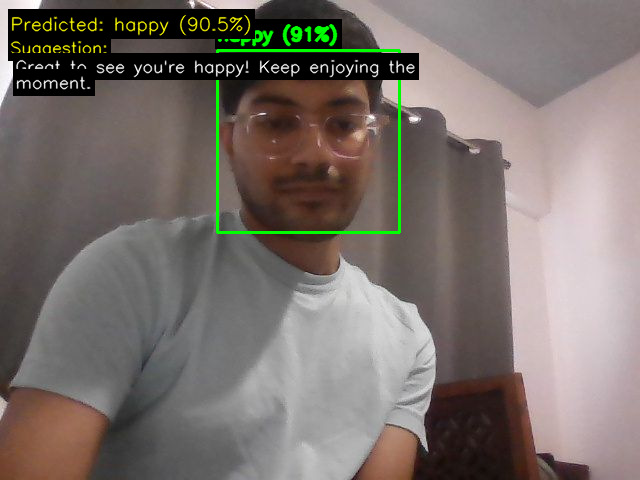


✅✅✅ Live Prediction Cycle Complete ✅✅✅

================= Script Execution Finished =================


--- Discussion & Improvement Ideas (3-Class Model) ---

1. Analysis of Misclassifications:
   - Examine the 3x3 confusion matrix generated in Step 8.5.
   - Focus on the largest off-diagonal values. For example, is 'Sad' often confused with 'Neutral'?
   - Potential Reasons for Sad <-> Neutral Confusion:
     - Visual Subtlety: Neutral faces and subtly sad faces can look very similar, especially in low-res FER images.
     - Acoustic Similarity: Low-energy sad speech might sound similar to calm neutral speech.
     - Merged Classes: Mapping multiple original negative emotions (Angry, Fear, Disgust) into 'Sad', and 'Surprise' into 'Neutral' creates broader, potentially overlapping target classes.
     - Data Imbalance: Check the counts per class after mapping (printed in Step 6). If one class heavily dominates, the model might be biased.
     - Feature Limitations: Current features m

In [36]:
# Step 11: Main Execution Block
# ============================================================
print("\n" + "="*15 + " Step 11: Running Main Execution Block (3 Classes) " + "="*15)
if __name__ == "__main__":
    print("\nChecking prerequisites for live prediction execution...")
    model_ready = 'model' in globals() and model is not None and model_built_flag
    cascade_ready = 'face_cascade' in globals() and face_cascade is not None
    bonn_data_ok = 'bonn_data_present' in globals() and bonn_data_present # Check flag from Step 1.6
    live_env_ok = IN_COLAB
    print(f"  - Model Ready: {model_ready}, Cascade Ready: {cascade_ready}, Bonn Data OK: {bonn_data_ok}, Live Env OK: {live_env_ok}")

    if model_ready and cascade_ready and bonn_data_ok and live_env_ok:
        print("\n✅ All prerequisites met for live prediction.")
        print("Verifying model weights state...")
        weights_available = False; training_occurred = 'history' in globals() and history is not None; es_restored = False
        if training_occurred and 'es' in globals(): es_restored = es.stopped_epoch > 0 and hasattr(es, 'best_weights') and es.best_weights is not None
        if es_restored: print("  - Using ES restored weights (best val_loss)."); weights_available = True
        elif os.path.exists(model_weights_filename):
            try: print(f"  - Loading best weights from: {model_weights_filename}"); model.load_weights(model_weights_filename); print("  - Best weights (val_acc) loaded."); weights_available = True
            except Exception as e: print(f"  - WARNING: Error loading weights: {e}. Proceeding with current state."); weights_available = True # Allow attempt
        elif training_occurred: print(f"  - WARNING: Using weights from end of training (no restore/file: {model_weights_filename})."); weights_available = True
        else: print("  - WARNING: Model likely untrained (no history/file)."); weights_available = True

        if weights_available:
            print("\nInitiating live prediction cycle (3 Classes)...")
            try: run_live_prediction_colab_visual_3class( model_obj=model, bonn_path=COLAB_BONN_PATH, face_cascade_obj=face_cascade )
            except Exception as main_e: print(f"\n--- 💥 UNEXPECTED ERROR during live prediction execution ---"); print(f"{main_e}"); traceback.print_exc()
        else: print("\nSkipping live prediction: Issues loading usable weights.")
    elif not live_env_ok: print("\nSkipping live prediction: Not running in Google Colab environment.")
    else:
        print("\n❌ ERROR: Not all prerequisites met for running live prediction.")
        if not model_ready: print("  - Issue: Model is not built or ready.")
        if not cascade_ready: print("  - Issue: Face detection cascade failed to load.")
        if not bonn_data_ok: print("  - Issue: Bonn EEG data seems missing or path is invalid (check Step 1.6).")
        print("Please review previous steps.")

    print("\n" + "="*17 + " Script Execution Finished " + "="*17)

# ============================================================
# --- Discussion Points & Further Improvements ---
# ============================================================
print("\n\n" + "="*20 + "\n--- Discussion & Improvement Ideas (3-Class Model) ---\n" + "="*20)
print("\n1. Analysis of Misclassifications:")
print("   - Examine the 3x3 confusion matrix generated in Step 8.5.")
print("   - Focus on the largest off-diagonal values. For example, is 'Sad' often confused with 'Neutral'?")
print("   - Potential Reasons for Sad <-> Neutral Confusion:")
print("     - Visual Subtlety: Neutral faces and subtly sad faces can look very similar, especially in low-res FER images.")
print("     - Acoustic Similarity: Low-energy sad speech might sound similar to calm neutral speech.")
print("     - Merged Classes: Mapping multiple original negative emotions (Angry, Fear, Disgust) into 'Sad', and 'Surprise' into 'Neutral' creates broader, potentially overlapping target classes.")
print("     - Data Imbalance: Check the counts per class after mapping (printed in Step 6). If one class heavily dominates, the model might be biased.")
print("     - Feature Limitations: Current features might struggle to separate nuanced differences between these broader categories.")
print("     - EEG Heuristics: The combined Bonn categories for 'Sad' (S, F) and 'Neutral' (Z, O, N) might not provide strong enough distinguishing signals.")
print("   - Action: Manually inspect some misclassified examples (video frame + audio if paired) to understand *why* the model failed.")
print("\n2. Hyperparameter Tuning:")
print("   - Learning Rate (LR): Crucial. Start lower (e.g., 1e-4, 5e-5) with Adam/AdamW. Use ReduceLROnPlateau or other schedulers.")
print("   - Batch Size: Try 16, 32, 64. Smaller batches need lower LR generally.")
print("   - Dropout Rates: Tune branch dropout (e.g., 0.3-0.5) and fused layer dropout (e.g., 0.4-0.6).")
print("   - Optimizer: AdamW often performs well. Experiment with weight decay values (e.g., 1e-4, 1e-5).")
print("   - Network Architecture: Adjust Dense layer units (e.g., 64, 128, 256) or add/remove layers.")
print("   - Regularization (L2): Tune the `l2_reg` factor (e.g., 1e-4, 1e-5, 1e-6).")
print("   - Systematic Search: Use tools like KerasTuner (Hyperband, BayesianOptimization) for efficient searching.")
print("\n3. Feature Fusion Techniques:")
print("   - Concatenation (Current): Simple baseline.")
print("   - Attention (Example Provided): `build_multimodal_model_attention` uses self-attention over concatenated features. Helps weigh modality importance.")
print("     - Try Cross-Modal Attention: Model how one modality affects the interpretation of another (e.g., video queries audio). More complex.")
print("   - Bilinear Pooling: Captures pairwise interactions (tf.einsum). Can generate large feature vectors needing reduction.")
print("   - Gated Multimodal Units (GMU): Learnable gates control information flow.")
print("   - Experiment: Try the provided Attention model (`USE_ATTENTION_FUSION = True`) and compare results.")
print("\n4. Evaluating EEG Contribution (Ablation Study):")
print("   - Goal: Determine if the heuristic EEG features help, hurt, or have no effect.")
print("   - Method: Train an identical model *without* the EEG branch.")
print("     1. Define `build_video_audio_model(video_dim, audio_dim, ...)`: Remove EEG input layer, EEG branch, and modify Concatenate to `([vid_processed, aud_processed])`.")
print("     2. Build this 2-input model instance.")
print("     3. Train: Use `model.fit([X_train_vid, X_train_aud], y_train, ...)` providing only Vid/Aud data.")
print("     4. Evaluate: Evaluate on `[X_val_vid, X_val_aud]` and `y_val`.")
print("     5. Compare: Compare metrics (Acc, F1 per class) of Vid+Aud model vs. Vid+Aud+EEG model.")
print("        - V+A+EEG Better -> EEG adds value.")
print("        - Similar -> EEG doesn't add much value (or fusion fails to use it).")
print("        - V+A+EEG Worse -> EEG adds noise.")
print("\n5. Data Augmentation & Quality:")
print("   - Video Augmentation: Explore more advanced techniques (e.g., Random Erasing, Mixup, CutMix, affine transformations via libraries like Albumentations).")
print("   - Audio Augmentation: Add more types (e.g., changing pitch, adding background noise from datasets like ESC-50).")
print("   - Address Imbalance: If severe imbalance persists after mapping, consider oversampling minority classes (e.g., SMOTE - careful with high-dim features) or undersampling majority classes.")
print("   - Data Cleaning: Visually inspect samples from FER classes that map to 'Sad'/'Neutral' to see if inherent ambiguity is high.")